In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --build --run

In [2]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,412 bytes  10,308.67 bytes/sec
total size is 7,657,910  speedup is 495.24
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/sblgpf_l1d'

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
           tag  IPC_IMPROVEMENT
0  childpf_l1d         0.004570
1  childpf_l2c         0.004155
2  childpf_llc         0.003636
3   sblgpf_l1d         0.003526
5   sblgpf_llc         0.001949
4   sblgpf_l2c         0.001307
sblgpf_l1d:0.020206745138326366
sblgpf_l2c:0.019188293758351568
sblgpf_llc:0.005238144040097431
childpf_l1d:0.016601339823919564
childpf_l2c:0.005586984992462684
childpf_llc:0.0032572525702771107
  benchmarks          tag      mean
0       mean   sblgpf_l1d  0.020207
1       mean   sblgpf_l2c  0.019188
2       mean   sblgpf_llc  0.005238
3       mean  childpf_l1d  0.016601
4       mean  childpf_l2c  0.005587
5       mean  childpf_llc  0.003

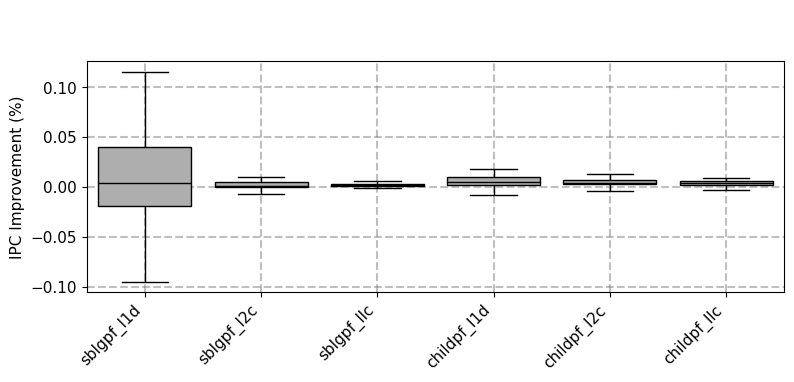

In [3]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot

from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

#display(Image("./figures/prefetch_buffer_eval/prefetch_buffer_eval_txvc_prefetch_funnel_selected_qualcomm_srv_ap.png", 
#width=600, height=600))



### Child Stage/Coverage Analysis (Prefetch Buffer Eval)


In [ ]:
# Boxplots across benchmarks for child-prefetch + prefetch-buffer runs
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve workspace root whether the notebook runs from repo root or notebooks/.
base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

# Output directory for exported figures
pdf_out_dir = base_dir / "figures" / "prefetch_buffer_eval"
pdf_out_dir.mkdir(parents=True, exist_ok=True)

required_raw = [
    "TXVC_CHILD_DROP_LEVEL0_SKIP",
    "TXVC_CHILD_DROP_LEAF_NO_PREDICT",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION",
    "TXVC_CHILD_DROP_PRED_INVALID",
    "TXVC_CHILD_DROP_PRED_TAG_MISMATCH",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED",
    "TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED",
]

# Use existing dataframe if it already contains child-drop counters; otherwise auto-load
# from parsed prefetch_buffer_eval outputs.
if (
    "d" in globals()
    and isinstance(d, pd.DataFrame)
    and not d.empty
    and all(c in d.columns for c in required_raw)
):
    box_df = d.copy()
else:
    preferred = sorted(
        (base_dir / "stats" / "prefetch_buffer_eval").glob(
            "**/*childpf*pfbuffer-L2C*/selected_*.csv"
        )
    )
    fallback = sorted((base_dir / "stats" / "prefetch_buffer_eval").glob("**/*childpf*/*.csv"))
    candidates = preferred + fallback

    box_df = None
    loaded_path = None
    for p in candidates:
        if not p.exists():
            continue
        try:
            tmp = pd.read_csv(p)
        except Exception:
            continue
        if all(c in tmp.columns for c in required_raw):
            box_df = tmp
            loaded_path = p
            break

    if box_df is None:
        raise RuntimeError(
            "Could not find a parsed CSV with TXVC child drop columns under stats/prefetch_buffer_eval. "
            "Run --parse first, or provide dataframe d in a previous cell."
        )

    print(f"Auto-loaded {len(box_df)} rows from {loaded_path}")

if "__bench" not in box_df.columns:
    if "benchmarks" in box_df.columns:
        box_df["__bench"] = box_df["benchmarks"].astype(str).str.strip()
    else:
        box_df["__bench"] = "unknown"

for c in required_raw:
    box_df[c] = pd.to_numeric(box_df[c], errors="coerce").fillna(0)

# Keep one representative row per benchmark to avoid duplicate rows from merged outputs.
box_df["_child_total"] = box_df[required_raw].sum(axis=1)
box_df = box_df.sort_values("_child_total", ascending=False).drop_duplicates("__bench").copy()

# Build composite counters
box_df["child_not_eligible"] = (
    box_df["TXVC_CHILD_DROP_LEVEL0_SKIP"] + box_df["TXVC_CHILD_DROP_LEAF_NO_PREDICT"]
)
box_df["child_structural_miss"] = (
    box_df["TXVC_CHILD_DROP_PRED_INVALID"] + box_df["TXVC_CHILD_DROP_PRED_TAG_MISMATCH"]
)
box_df["child_backend_blocked"] = (
    box_df["TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED"] + box_df["TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED"]
)

# Stage components for distribution plots
stage_budget = (
    box_df["child_not_eligible"]
    + box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"]
    + box_df["TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION"]
    + box_df["child_structural_miss"]
    + box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"]
    + box_df["TXVC_CHILD_DROP_PRED_ISSUED"]
    + box_df["child_backend_blocked"]
).replace(0, np.nan)

box_df["not_eligible_pct"] = 100.0 * box_df["child_not_eligible"] / stage_budget
box_df["no_parent_ctx_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"] / stage_budget
box_df["structural_miss_pct"] = 100.0 * box_df["child_structural_miss"] / stage_budget
box_df["conf_blocked_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"] / stage_budget
box_df["backend_blocked_pct"] = 100.0 * box_df["child_backend_blocked"] / stage_budget
box_df["issued_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget

box_df["child_potential_coverage_pct"] = 100.0 * (
    box_df["TXVC_CHILD_DROP_PRED_ISSUED"] + box_df["child_backend_blocked"]
) / stage_budget
box_df["child_realized_coverage_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget

# 1) Distribution of stage shares across benchmarks
stage_metrics = [
    "not_eligible_pct",
    "no_parent_ctx_pct",
    "structural_miss_pct",
    "conf_blocked_pct",
    "backend_blocked_pct",
    "issued_pct",
]
stage_long = box_df.melt(value_vars=stage_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(12, 6))
sns.boxplot(data=stage_long, x="metric", y="pct", color="#8ecae6", showfliers=False)
sns.stripplot(data=stage_long, x="metric", y="pct", color="#023047", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("events (%)")
plt.xticks(rotation=25)
plt.tight_layout()
stage_pdf = pdf_out_dir / "prefetch_buffer_child_stage_share_boxplot.pdf"
plt.savefig(stage_pdf, format="pdf", bbox_inches="tight")
plt.show()

# 2) Coverage distributions across benchmarks
cov_metrics = [
    "child_potential_coverage_pct",
    "child_realized_coverage_pct",
]
cov_long = box_df.melt(value_vars=cov_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(10, 6))
sns.boxplot(data=cov_long, x="metric", y="pct", color="#bde0fe", showfliers=False)
sns.stripplot(data=cov_long, x="metric", y="pct", color="#1d3557", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("Coverage (%)")
plt.xticks(rotation=20)
plt.tight_layout()
coverage_pdf = pdf_out_dir / "prefetch_buffer_child_coverage_boxplot.pdf"
plt.savefig(coverage_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved PDF: {stage_pdf}")
print(f"Saved PDF: {coverage_pdf}")

# Optional: low-realized-coverage outliers
outlier_view = box_df[[
    "__bench",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "child_not_eligible",
    "child_structural_miss",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "child_backend_blocked",
    "child_potential_coverage_pct",
    "child_realized_coverage_pct",
]].copy()

outlier_view.sort_values("child_realized_coverage_pct", ascending=True).head(15)

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.plot_type='prefetch_accuracy, prefetch_coverage'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_accuracy_selected_qualcomm_srv_ap.png

=== PREFETCH_ACCURACY Statistics (%) ===
sblgpf_l1d           count=100  min= 67.61  q1= 75.20  median= 78.45  q3= 81.73  max= 93.98  mean= 78.64
sblgpf_l2c           count=100  min= 16.67  q1= 37.50  median= 44.14  q3= 50.00  max= 84.92  mean= 45.25
sblgpf_llc           count=100  min= 21.43  q1= 45.10  median= 52.66  q3= 60.12  max= 86.11  mean= 52.91
childpf_l1d          count=100  min= 89.29  q1= 95.35  median= 97.07  q3= 97.85  max=101.43  mean= 96.42
childpf_l2c          count=100  min= 14.43  q1= 47.04  median= 60.94  q3= 68.34  max= 93.44  mean= 58.06
childpf_llc   

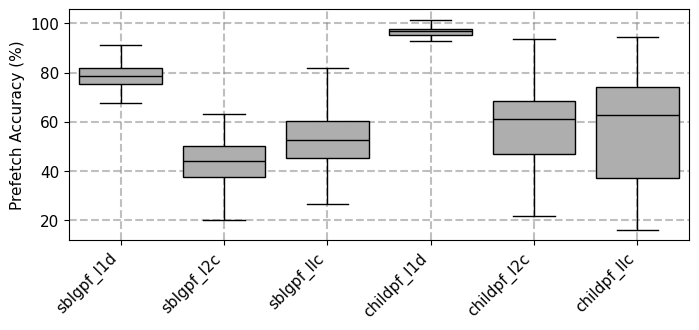

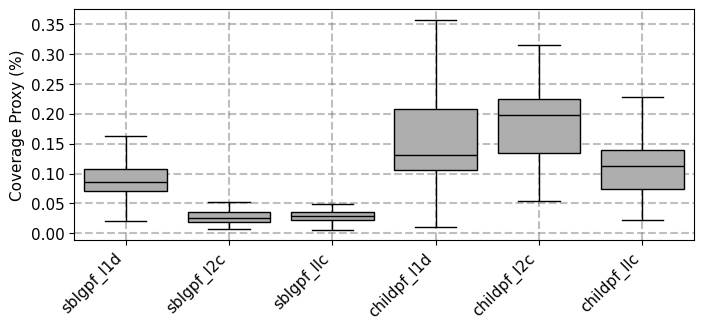

In [ ]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --override "PLOTTING.plot_type=prefetch_accuracy" --plot

from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_accuracy_selected_qualcomm_srv_ap.png", 
width=600, height=600))

### Actual Coverage Calculation (vs BASELINE)

Compute **true coverage** by comparing against BASELINE using the new `prefetch_coverage_true` plot type in `champsim2plot.py`:

**Formula:**
```
Actual Coverage = (baseline_misses - prefetcher_misses) / baseline_misses × 100%
```

**Key Differences:**

| Metric | Formula | Range | Meaning |
|--------|---------|-------|---------|
| **Coverage Proxy** | useful / remaining_misses | 0-∞% (can exceed 100%) | Efficiency: useful prefetches per remaining miss |
| **Actual Coverage** | miss_reduction / baseline_misses | 0-100% | Effectiveness: percentage of baseline misses prevented |

The proxy is useful for quick analysis without baseline runs, but actual coverage shows true performance impact.

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.plot_type='prefetch_coverage_true'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_coverage_true_selected_qualcomm_srv_ap.png

=== ACTUAL_COVERAGE Statistics (%) ===
sblgpf_l1d           count=100  min= -2.27  q1= -0.06  median=  0.09  q3=  0.22  max=  5.27  mean=  0.10
sblgpf_l2c           count=100  min= -6.65  q1=  0.01  median=  0.02  q3=  0.04  max=  4.00  mean=  0.04
sblgpf_llc           count=100  min= -2.65  q1=  0.02  median=  0.03  q3=  0.04  max=  3.79  mean= -0.05
childpf_l1d          count=100  min= -1.30  q1= -0.00  median=  0.06  q3=  0.15  max=  4.87  mean=  0.12
childpf_l2c          count=100  min= -2.05  q1=  0.03  median=  0.05  q3=  0.07  max=  0.58  mean=  0.03
childpf_llc          coun

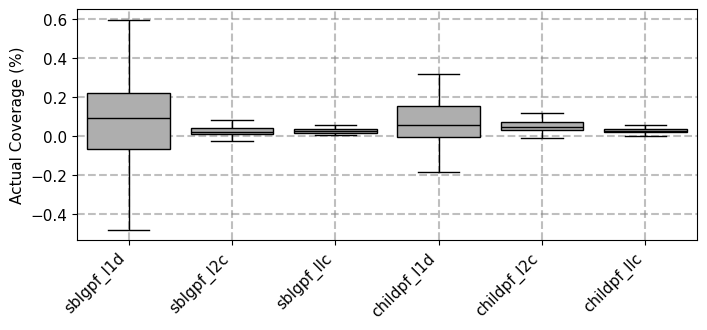

In [6]:
# Compute and plot actual coverage using champsim2plot.py
%cd /home/bscuser/synched_mnt/VMem

# Generate actual coverage plot
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --override "PLOTTING.plot_type=prefetch_coverage_true" --plot

# Display the generated plot
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_coverage_true_selected_qualcomm_srv_ap.png", 
              width=600, height=600))

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.plot_type='prefetch_coverage, prefetch_coverage_true'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_coverage_selected_qualcomm_srv_ap.png

=== PREFETCH_COVERAGE Statistics (%) ===
sblgpf_l1d           count=100  min=  0.02  q1=  0.07  median=  0.09  q3=  0.11  max=  0.18  mean=  0.09
sblgpf_l2c           count=100  min=  0.01  q1=  0.02  median=  0.03  q3=  0.04  max=  0.38  mean=  0.03
sblgpf_llc           count=100  min=  0.01  q1=  0.02  median=  0.03  q3=  0.04  max=  0.36  mean=  0.04
childpf_l1d          count=100  min=  0.01  q1=  0.11  median=  0.13  q3=  0.21  max=  0.36  mean=  0.16
childpf_l2c          count=100  min=  0.05  q1=  0.13  median=  0.20  q3=  0.22  max=  0.55  mean=  0.19
childpf_l

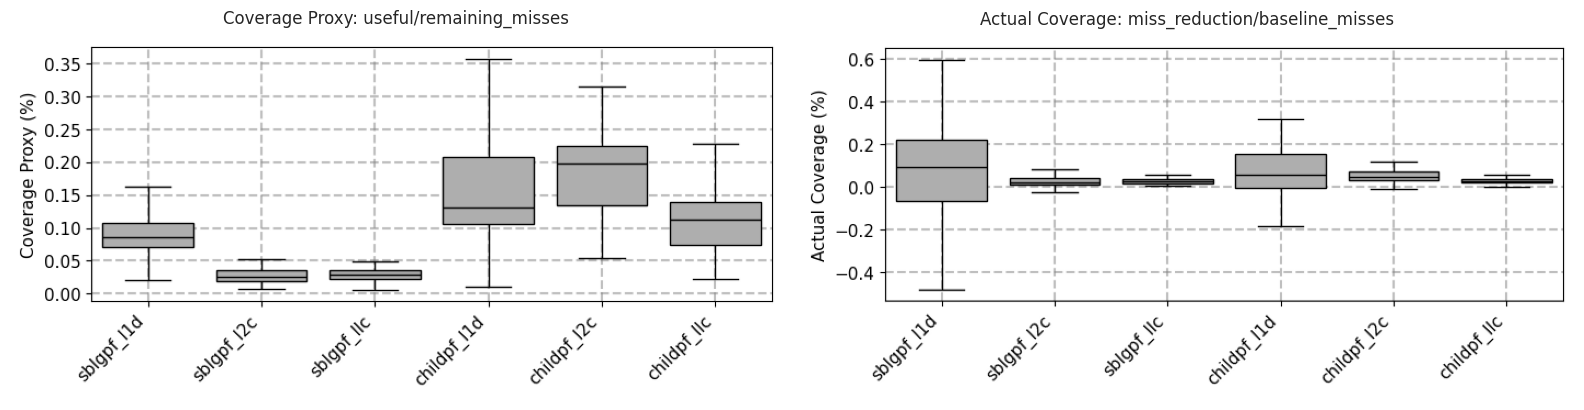


Key Differences:
• Coverage Proxy: Measures useful prefetches relative to REMAINING misses (can be >100%)
• Actual Coverage: Measures miss reduction relative to BASELINE misses (0-100%)


In [7]:
# Compare coverage proxy vs actual coverage side-by-side
%cd /home/bscuser/synched_mnt/VMem

# Generate both plots
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --override "PLOTTING.plot_type=prefetch_coverage, prefetch_coverage_true" --plot

# Display both plots for comparison
from IPython.display import Image, display
import matplotlib.pyplot as plt
from PIL import Image as PILImage

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coverage Proxy (can exceed 100%)
img1 = PILImage.open("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_coverage_selected_qualcomm_srv_ap.png")
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Coverage Proxy: useful/remaining_misses", fontsize=12, pad=10)

# Actual Coverage (0-100%)
img2 = PILImage.open("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_prefetch_coverage_true_selected_qualcomm_srv_ap.png")
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Actual Coverage: miss_reduction/baseline_misses", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("• Coverage Proxy: Measures useful prefetches relative to REMAINING misses (can be >100%)")
print("• Actual Coverage: Measures miss reduction relative to BASELINE misses (0-100%)")

***
### PTE Level Access Distribution by Cache

Visualize the distribution of page table accesses across different PTE levels (0-4) for each cache level (L1D, L2C, LLC, TXVC).

In [ ]:
%cd /home/bscuser/synched_mnt/VMem

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_theme(style="whitegrid")

# Base directory setup
base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

# Directory containing CSV files
csv_dir = base_dir / "stats" / "tx_prefetch_eval_unlimited"
output_dir = base_dir / "figures" / "tx_prefetch_eval_unlimited" / "pte_level_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

# Find all CSV files in the directory
csv_files = sorted(csv_dir.glob("**/*.csv"))

if not csv_files:
    print(f"No CSV files found in {csv_dir}")
else:
    print(f"Found {len(csv_files)} CSV files\n")
    
    # Track how many plots we create
    plots_created = 0
    
    # Try to load one to check for PTE level columns
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            
            # Check if we have PTE level access columns
            pte_cols = [col for col in df.columns if 'pte_level_accesses' in col]
            
            if not pte_cols:
                print(f"⚠️  No PTE level columns in {csv_file.name}")
                print("   Expected columns like: L1D_pte_level_accesses_0, L2C_pte_level_accesses_1, etc.")
                print("   Please ensure champsim2csv.py has been updated and experiments re-parsed.\n")
                continue
            
            # Get benchmark name
            if '__bench' in df.columns:
                benchmarks = df['__bench'].unique()
            elif 'benchmarks' in df.columns:
                benchmarks = df['benchmarks'].unique()
            else:
                benchmarks = ['unknown']
            
            # For each benchmark, create a plot
            for benchmark in benchmarks:
                if '__bench' in df.columns:
                    bench_df = df[df['__bench'] == benchmark]
                elif 'benchmarks' in df.columns:
                    bench_df = df[df['benchmarks'] == benchmark]
                else:
                    bench_df = df
                
                # Prepare data for plotting
                plot_data = []
                
                # Cache levels to analyze
                cache_levels = ['L1D', 'L2C', 'LLC', 'TXVC']
                pte_levels = range(5)  # PTE levels 0-4
                
                for cache in cache_levels:
                    for pte_level in pte_levels:
                        col_name = f'{cache}_pte_level_accesses_{pte_level}'
                        if col_name in bench_df.columns:
                            accesses = bench_df[col_name].values[0] if len(bench_df) > 0 else 0
                            plot_data.append({
                                'Cache': cache,
                                'PTE Level': pte_level,
                                'Accesses': accesses
                            })
                
                if not plot_data:
                    print(f"⚠️  No PTE data found for benchmark: {benchmark}")
                    continue
                
                plot_df = pd.DataFrame(plot_data)
                
                # Filter out caches with zero accesses
                cache_totals = plot_df.groupby('Cache')['Accesses'].sum()
                active_caches = cache_totals[cache_totals > 0].index.tolist()
                plot_df = plot_df[plot_df['Cache'].isin(active_caches)]
                
                if plot_df.empty or plot_df['Accesses'].sum() == 0:
                    print(f"⚠️  No PTE accesses recorded for benchmark: {benchmark}")
                    continue
                
                # Create the clustered bar plot
                fig, ax = plt.subplots(figsize=(12, 6))
                
                # Use seaborn barplot with PTE level as x-axis and cache as hue for better clustering
                sns.barplot(
                    data=plot_df,
                    x='PTE Level',
                    y='Accesses',
                    hue='Cache',
                    palette='Set2',
                    ax=ax
                )
                
                ax.set_title(f'PTE Level Access Distribution - {benchmark}', fontsize=14, fontweight='bold')
                ax.set_xlabel('PTE Level', fontsize=12)
                ax.set_ylabel('Number of Accesses', fontsize=12)
                ax.legend(title='Cache Level', bbox_to_anchor=(1.05, 1), loc='upper left')
                
                # Format y-axis with scientific notation if needed
                if plot_df['Accesses'].max() > 10000:
                    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
                
                plt.tight_layout()
                
                # Save figure
                output_file = output_dir / f'pte_level_accesses_{benchmark}.pdf'
                plt.savefig(output_file, format='pdf', bbox_inches='tight')
                
                # Display in notebook
                plt.show()
                
                print(f"✓ Saved: {output_file.name}")
                plots_created += 1
            
        except Exception as e:
            print(f"❌ Error processing {csv_file.name}: {e}")
            continue

if plots_created > 0:
    print(f"\n{'='*60}")
    print(f"✓ Created {plots_created} plot(s)")
    print(f"✓ All plots saved to: {output_dir}")
else:
    print(f"\n{'='*60}")
    print("⚠️  No plots were created.")
    print("   Next steps:")
    print("   1. Rebuild ChampSim with cache.cc and cache.h fixes")
    print("   2. Regenerate configs with params_registry fix") 
    print("   3. Rerun experiments to generate PTE statistics")
    print("   4. Parse with --parse to create CSVs with PTE columns")

/home/bscuser/synched_mnt/VMem
BASELINE PTE demand ACCESS composition by cache (%):
          L0     L1    L2    L3   L4
CACHE                               
L1D    81.42  18.33  0.19  0.05  0.0
L2C    78.86  20.80  0.26  0.07  0.0
LLC    91.36   8.33  0.24  0.08  0.0

BASELINE PTE demand MISS composition by cache (%):
          L0     L1    L2    L3   L4
CACHE                               
L1D    82.44  17.29  0.21  0.06  0.0
L2C    91.36   8.33  0.24  0.08  0.0
LLC    92.70   6.99  0.23  0.08  0.0


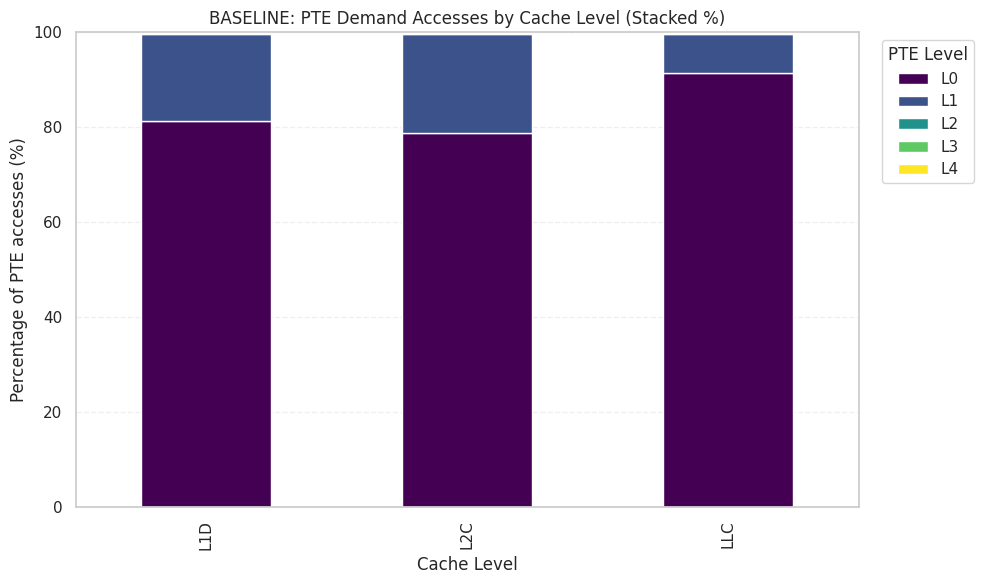

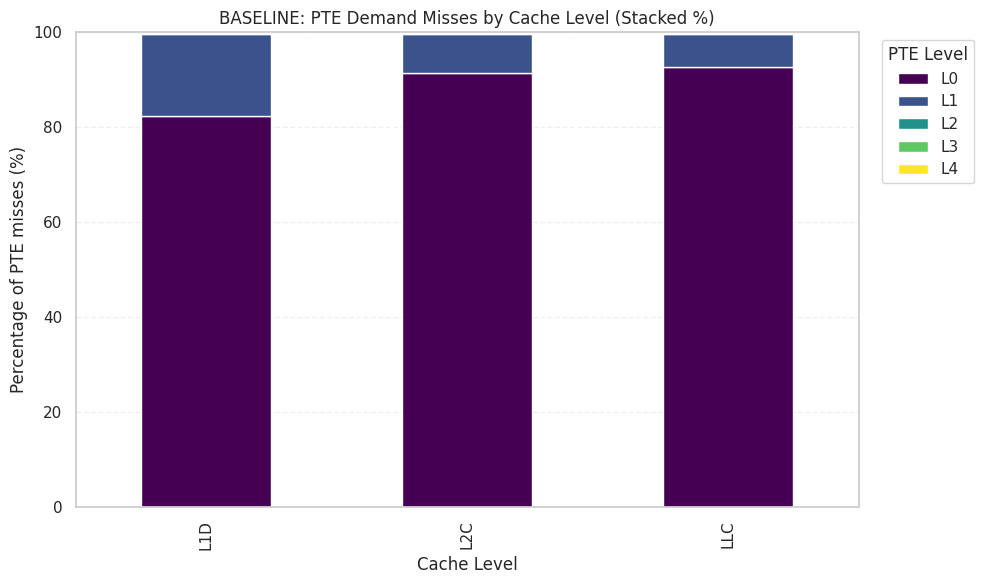


Saved accesses plot: /home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/pte_demand_by_cache/BASELINE_pte_demand_accesses_by_cache_stacked_pct.pdf
Saved misses plot: /home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/pte_demand_by_cache/BASELINE_pte_demand_misses_by_cache_stacked_pct.pdf


In [ ]:
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()

# Focus only on BASELINE
sim = "BASELINE"

stats_root = base_dir / "stats" / exp_name
fig_root = base_dir / "figures" / exp_name / "pte_demand_by_cache"
fig_root.mkdir(parents=True, exist_ok=True)

cache_map = {
    "cpu0_L1D": "L1D",
    "cpu0_L2C": "L2C",
    "LLC": "LLC",
}
access_cols = [f"pte_level_accesses_{i}" for i in range(5)]
miss_cols = [f"pte_level_misses_{i}" for i in range(5)]

csv_path = stats_root / sim / f"{workload}_{sim}.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Missing file: {csv_path}")

df = pd.read_csv(csv_path)

required_cols = access_cols + miss_cols
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing PTE columns: {missing_cols}")

if "CACHE" not in df.columns or "OP" not in df.columns:
    raise ValueError("CSV missing CACHE/OP columns")

# Demand-side translation traffic only.
d = df[(df["CACHE"].isin(cache_map.keys())) & (df["OP"] == "TRANSLATION")].copy()
if d.empty:
    raise ValueError("No TRANSLATION rows for L1D/L2C/LLC in BASELINE")

for c in required_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0)

# Sum across all benchmarks.
summed_access = d.groupby("CACHE", as_index=False)[access_cols].sum()
summed_miss = d.groupby("CACHE", as_index=False)[miss_cols].sum()

# Friendly cache labels
summed_access["CACHE"] = summed_access["CACHE"].map(cache_map)
summed_miss["CACHE"] = summed_miss["CACHE"].map(cache_map)

# Ensure fixed cache order
cache_order = ["L1D", "L2C", "LLC"]
summed_access = summed_access.set_index("CACHE").reindex(cache_order).fillna(0)
summed_miss = summed_miss.set_index("CACHE").reindex(cache_order).fillna(0)

# Convert to percentages within each cache
access_tot = summed_access.sum(axis=1).replace(0, pd.NA)
miss_tot = summed_miss.sum(axis=1).replace(0, pd.NA)
access_pct = (summed_access.div(access_tot, axis=0) * 100).fillna(0)
miss_pct = (summed_miss.div(miss_tot, axis=0) * 100).fillna(0)

# Pretty column labels
access_pct.columns = [f"L{i}" for i in range(5)]
miss_pct.columns = [f"L{i}" for i in range(5)]

print("BASELINE PTE demand ACCESS composition by cache (%):")
print(access_pct.round(2))
print("\nBASELINE PTE demand MISS composition by cache (%):")
print(miss_pct.round(2))

# Stacked bar: Access percentages
fig, ax = plt.subplots(figsize=(10, 6))
access_pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("BASELINE: PTE Demand Accesses by Cache Level (Stacked %)")
ax.set_xlabel("Cache Level")
ax.set_ylabel("Percentage of PTE accesses (%)")
ax.set_ylim(0, 100)
ax.legend(title="PTE Level", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out_access = fig_root / "BASELINE_pte_demand_accesses_by_cache_stacked_pct.png"
plt.savefig(out_access, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# Stacked bar: Miss percentages
fig, ax = plt.subplots(figsize=(10, 6))
miss_pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("BASELINE: PTE Demand Misses by Cache Level (Stacked %)")
ax.set_xlabel("Cache Level")
ax.set_ylabel("Percentage of PTE misses (%)")
ax.set_ylim(0, 100)
ax.legend(title="PTE Level", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out_miss = fig_root / "BASELINE_pte_demand_misses_by_cache_stacked_pct.png"
plt.savefig(out_miss, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved accesses plot: {out_access}")
print(f"Saved misses plot: {out_miss}")

* Vast Majority are leaf nodes. 
  - No much opportunity for child prefetcher to issue a prefetch, it has to be at least L1D.
  - Combining with sibling might help, but sibling also does not perform very well.

* What is the main issue though? No chance for prefetching or no candidates are found?  

### Child Prefetcher Limitation Breakdown

Use parsed child-prefetch counters to answer:
- Is the policy **leaf-node limited**?
- Is it blocked by **missing training/context**?

This section creates:
1. Stacked drop-reason composition (%) per childpf experiment
2. Leaf-limited vs no-training composite (%) per childpf experiment
3. Entry pressure ratios (replacements/allocations, etc.)

/home/bscuser/synched_mnt/VMem
Childpf aggregate counters:
        sim  total_drop  leaf_limited  no_training  conf_blocked  issued  backend_blocked  pending_collision  repl_over_alloc_pct  repl_before_issue_over_repl_pct  live_with_issue_over_live_pct
childpf_l1d  14405244.0     5123881.0    5020307.0       17425.0 41991.0        4172186.0            29454.0                 3.17                            94.55                          30.03
childpf_l2c   8678460.0     4350186.0    4247649.0       17366.0 41336.0              0.0            21923.0                 3.52                            93.13                          30.04
childpf_llc   2009537.0     1003953.0     975761.0       10207.0 17584.0              0.0             2032.0                 2.49                            91.74                          24.94


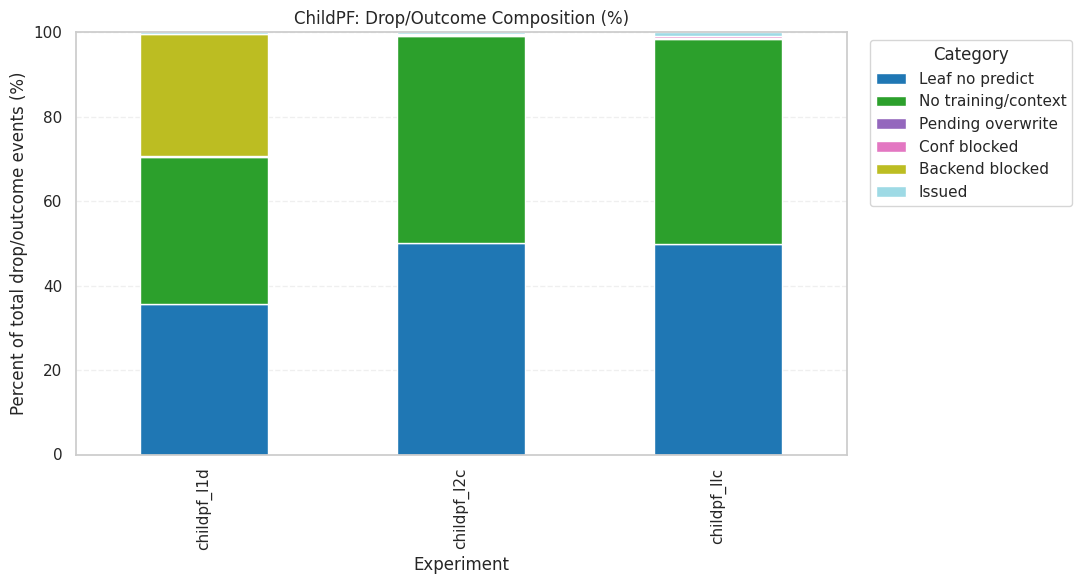

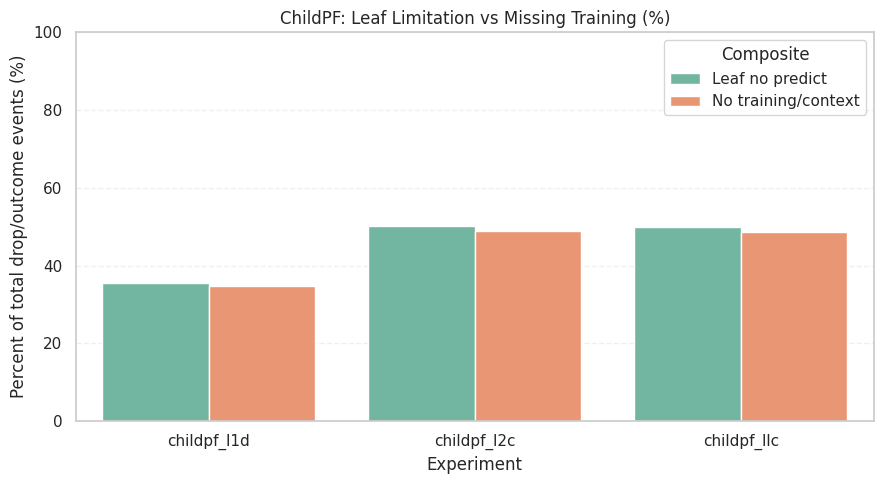

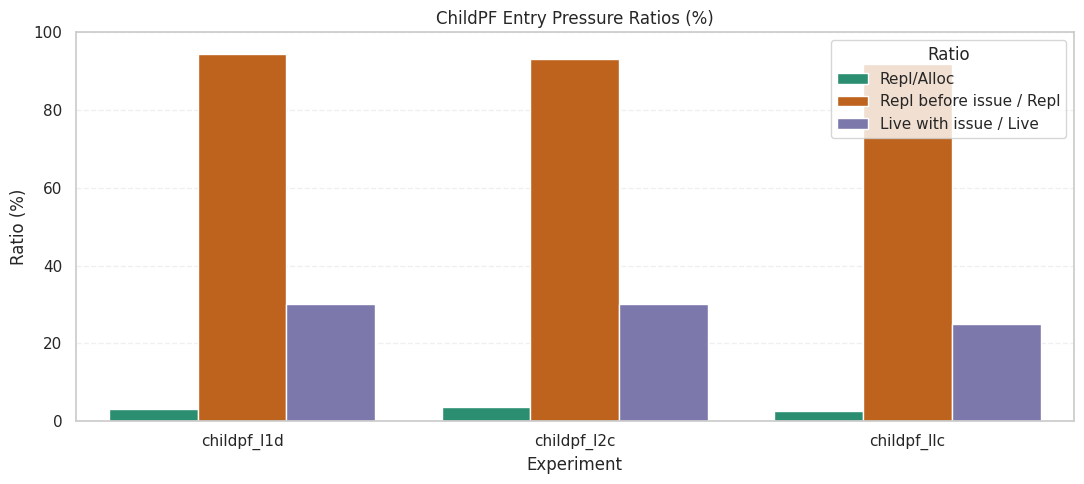


Saved: /home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/childpf_limit_breakdown/childpf_drop_composition_stacked_pct.pdf
Saved: /home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/childpf_limit_breakdown/childpf_leaf_vs_no_training_pct.pdf
Saved: /home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/childpf_limit_breakdown/childpf_entry_pressure_ratios_pct.pdf


In [ ]:
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()
all_sims = [s.strip() for s in config["EXPERIMENT"]["simulations"].split(",") if s.strip()]
child_sims = [s for s in all_sims if "childpf" in s.lower()]

stats_root = base_dir / "stats" / exp_name
fig_root = base_dir / "figures" / exp_name / "childpf_limit_breakdown"
fig_root.mkdir(parents=True, exist_ok=True)

drop_cols = [
    "TXVC_CHILD_DROP_LEVEL0_SKIP",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION",
    "TXVC_CHILD_DROP_TRAIN_REPLACE_MISMATCH",
    "TXVC_CHILD_DROP_LEAF_NO_PREDICT",
    "TXVC_CHILD_DROP_PRED_INVALID",
    "TXVC_CHILD_DROP_PRED_TAG_MISMATCH",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED",
    "TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED",
]
entry_cols = [
    "TXVC_PREFETCHER_ENTRY_ALLOC",
    "TXVC_PREFETCHER_ENTRY_REPL",
    "TXVC_PREFETCHER_ENTRY_REPL_BEFORE_ISSUE",
    "TXVC_PREFETCHER_ENTRY_REPL_AFTER_ISSUE",
    "TXVC_PREFETCHER_ENTRY_LIVE",
    "TXVC_PREFETCHER_ENTRY_LIVE_WITH_ISSUE",
]

rows = []
for sim in child_sims:
    csv_path = stats_root / sim / f"{workload}_{sim}.csv"
    if not csv_path.exists():
        print(f"Skipping {sim}: missing {csv_path.name}")
        continue

    df = pd.read_csv(csv_path)
    needed = drop_cols + entry_cols + ["CACHE", "OP", "benchmarks"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f"Skipping {sim}: missing columns {missing}")
        continue

    # These counters are run-global and repeated in many rows.
    # Keep one representative row per benchmark (CACHE=cpu0_L1D, OP=TOTAL is stable).
    rep = df[(df["CACHE"] == "cpu0_L1D") & (df["OP"] == "TOTAL")].copy()
    if rep.empty:
        rep = df.drop_duplicates("benchmarks").copy()

    for c in drop_cols + entry_cols:
        rep[c] = pd.to_numeric(rep[c], errors="coerce").fillna(0)

    sums = rep[drop_cols + entry_cols].sum()

    total_drop = float(sums[drop_cols].sum())
    leaf_limited = float(sums["TXVC_CHILD_DROP_LEAF_NO_PREDICT"])
    no_training = float(
        sums["TXVC_CHILD_DROP_NO_PENDING_PARENT"]
        + sums["TXVC_CHILD_DROP_PRED_INVALID"]
        + sums["TXVC_CHILD_DROP_PRED_TAG_MISMATCH"]
        + sums["TXVC_CHILD_DROP_TRAIN_REPLACE_MISMATCH"]
    )

    row = {
        "sim": sim,
        "total_drop": total_drop,
        "leaf_limited": leaf_limited,
        "no_training": no_training,
        "conf_blocked": float(sums["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"]),
        "issued": float(sums["TXVC_CHILD_DROP_PRED_ISSUED"]),
        "backend_blocked": float(sums["TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED"] + sums["TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED"]),
        "pending_collision": float(sums["TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION"]),
        "alloc": float(sums["TXVC_PREFETCHER_ENTRY_ALLOC"]),
        "repl": float(sums["TXVC_PREFETCHER_ENTRY_REPL"]),
        "repl_before_issue": float(sums["TXVC_PREFETCHER_ENTRY_REPL_BEFORE_ISSUE"]),
        "repl_after_issue": float(sums["TXVC_PREFETCHER_ENTRY_REPL_AFTER_ISSUE"]),
        "live": float(sums["TXVC_PREFETCHER_ENTRY_LIVE"]),
        "live_with_issue": float(sums["TXVC_PREFETCHER_ENTRY_LIVE_WITH_ISSUE"]),
    }
    rows.append(row)

if not rows:
    raise RuntimeError("No childpf data found. Re-run parser and ensure childpf CSVs exist.")

res = pd.DataFrame(rows)
res = res.sort_values("sim").reset_index(drop=True)

# Percent views
for c in ["leaf_limited", "no_training", "conf_blocked", "issued", "backend_blocked", "pending_collision"]:
    res[f"{c}_pct"] = np.where(res["total_drop"] > 0, 100.0 * res[c] / res["total_drop"], 0.0)

# Entry-pressure ratios
res["repl_over_alloc_pct"] = np.where(res["alloc"] > 0, 100.0 * res["repl"] / res["alloc"], 0.0)
res["repl_before_issue_over_repl_pct"] = np.where(res["repl"] > 0, 100.0 * res["repl_before_issue"] / res["repl"], 0.0)
res["live_with_issue_over_live_pct"] = np.where(res["live"] > 0, 100.0 * res["live_with_issue"] / res["live"], 0.0)

print("Childpf aggregate counters:")
display_cols = [
    "sim", "total_drop", "leaf_limited", "no_training", "conf_blocked", "issued", "backend_blocked", "pending_collision",
    "repl_over_alloc_pct", "repl_before_issue_over_repl_pct", "live_with_issue_over_live_pct"
]
print(res[display_cols].round(2).to_string(index=False))

# 1) Stacked drop-reason composition
stack_cols = [
    "leaf_limited_pct",
    "no_training_pct",
    "pending_collision_pct",
    "conf_blocked_pct",
    "backend_blocked_pct",
    "issued_pct",
]
stack_labels = [
    "Leaf no predict",
    "No training/context",
    "Pending overwrite",
    "Conf blocked",
    "Backend blocked",
    "Issued",
]

plot_stack = res[["sim"] + stack_cols].copy()
plot_stack.columns = ["sim"] + stack_labels
plot_stack = plot_stack.set_index("sim")

fig, ax = plt.subplots(figsize=(11, 6))
plot_stack.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("ChildPF: Drop/Outcome Composition (%)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Percent of total drop/outcome events (%)")
ax.set_ylim(0, 100)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out1 = fig_root / "childpf_drop_composition_stacked_pct.png"
plt.savefig(out1, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Leaf-limited vs no-training composite
comp = res[["sim", "leaf_limited_pct", "no_training_pct"]].copy()
comp_long = comp.melt(id_vars="sim", var_name="metric", value_name="pct")
comp_long["metric"] = comp_long["metric"].map({
    "leaf_limited_pct": "Leaf no predict",
    "no_training_pct": "No training/context",
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=comp_long, x="sim", y="pct", hue="metric", palette="Set2")
ax.set_title("ChildPF: Leaf Limitation vs Missing Training (%)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Percent of total drop/outcome events (%)")
ax.set_ylim(0, 100)
ax.legend(title="Composite")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out2 = fig_root / "childpf_leaf_vs_no_training_pct.png"
plt.savefig(out2, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Entry-pressure ratios
ratio_cols = ["repl_over_alloc_pct", "repl_before_issue_over_repl_pct", "live_with_issue_over_live_pct"]
ratio_long = res[["sim"] + ratio_cols].melt(id_vars="sim", var_name="metric", value_name="pct")
ratio_long["metric"] = ratio_long["metric"].map({
    "repl_over_alloc_pct": "Repl/Alloc",
    "repl_before_issue_over_repl_pct": "Repl before issue / Repl",
    "live_with_issue_over_live_pct": "Live with issue / Live",
})

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=ratio_long, x="sim", y="pct", hue="metric", palette="Dark2")
ax.set_title("ChildPF Entry Pressure Ratios (%)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Ratio (%)")
ax.set_ylim(0, 100)
ax.legend(title="Ratio")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out3 = fig_root / "childpf_entry_pressure_ratios_pct.png"
plt.savefig(out3, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved: {out1}")
print(f"Saved: {out2}")
print(f"Saved: {out3}")

### Sibling Prefetcher Limitation Breakdown

Same analysis as ChildPF, but for sibling-prefetcher experiments (`sblgpf_*`):
1. Stacked drop-reason composition (%)
2. Key bottleneck comparison (%)
3. Entry pressure ratios (%)

In [10]:
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()
all_sims = [s.strip() for s in config["EXPERIMENT"]["simulations"].split(",") if s.strip()]
sblg_sims = [s for s in all_sims if "sblgpf" in s.lower()]

stats_root = base_dir / "stats" / exp_name
fig_root = base_dir / "figures" / exp_name / "sblgpf_limit_breakdown"
fig_root.mkdir(parents=True, exist_ok=True)

# Parsed from PF SBLG DROP-REASONS line
drop_cols = [
    "TXVC_SBLG_DROP_LEVEL0_SKIP",
    "TXVC_SBLG_DROP_UC_DISABLED",
    "TXVC_SBLG_DROP_PRED_INVALID",
    "TXVC_SBLG_DROP_PRED_TAG_MISMATCH",
    "TXVC_SBLG_DROP_PRED_CONF_BLOCKED",
    "TXVC_SBLG_DROP_PRED_ZERO_DELTA",
    "TXVC_SBLG_DROP_PRED_ISSUED",
    "TXVC_SBLG_DROP_ISSUE_MSHR_BLOCKED",
    "TXVC_SBLG_DROP_ISSUE_ENQUEUE_FAILED",
]
entry_cols = [
    "TXVC_PREFETCHER_ENTRY_ALLOC",
    "TXVC_PREFETCHER_ENTRY_REPL",
    "TXVC_PREFETCHER_ENTRY_REPL_BEFORE_ISSUE",
    "TXVC_PREFETCHER_ENTRY_REPL_AFTER_ISSUE",
    "TXVC_PREFETCHER_ENTRY_LIVE",
    "TXVC_PREFETCHER_ENTRY_LIVE_WITH_ISSUE",
]

rows = []
for sim in sblg_sims:
    csv_path = stats_root / sim / f"{workload}_{sim}.csv"
    if not csv_path.exists():
        print(f"Skipping {sim}: missing {csv_path.name}")
        continue

    df = pd.read_csv(csv_path)
    needed = drop_cols + entry_cols + ["CACHE", "OP", "benchmarks"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f"Skipping {sim}: missing columns {missing}")
        continue

    # Counters are run-global and repeated; one row per benchmark is enough.
    rep = df[(df["CACHE"] == "cpu0_L1D") & (df["OP"] == "TOTAL")].copy()
    if rep.empty:
        rep = df.drop_duplicates("benchmarks").copy()

    for c in drop_cols + entry_cols:
        rep[c] = pd.to_numeric(rep[c], errors="coerce").fillna(0)

    sums = rep[drop_cols + entry_cols].sum()

    total_drop = float(sums[drop_cols].sum())
    row = {
        "sim": sim,
        "total_drop": total_drop,
        "uc_disabled": float(sums["TXVC_SBLG_DROP_UC_DISABLED"]),
        "pred_invalid": float(sums["TXVC_SBLG_DROP_PRED_INVALID"]),
        "pred_tag_mismatch": float(sums["TXVC_SBLG_DROP_PRED_TAG_MISMATCH"]),
        "pred_conf_blocked": float(sums["TXVC_SBLG_DROP_PRED_CONF_BLOCKED"]),
        "pred_zero_delta": float(sums["TXVC_SBLG_DROP_PRED_ZERO_DELTA"]),
        "pred_issued": float(sums["TXVC_SBLG_DROP_PRED_ISSUED"]),
        "backend_blocked": float(sums["TXVC_SBLG_DROP_ISSUE_MSHR_BLOCKED"] + sums["TXVC_SBLG_DROP_ISSUE_ENQUEUE_FAILED"]),
        "alloc": float(sums["TXVC_PREFETCHER_ENTRY_ALLOC"]),
        "repl": float(sums["TXVC_PREFETCHER_ENTRY_REPL"]),
        "repl_before_issue": float(sums["TXVC_PREFETCHER_ENTRY_REPL_BEFORE_ISSUE"]),
        "repl_after_issue": float(sums["TXVC_PREFETCHER_ENTRY_REPL_AFTER_ISSUE"]),
        "live": float(sums["TXVC_PREFETCHER_ENTRY_LIVE"]),
        "live_with_issue": float(sums["TXVC_PREFETCHER_ENTRY_LIVE_WITH_ISSUE"]),
    }
    rows.append(row)

if not rows:
    raise RuntimeError("No sibling-prefetch data found. Re-run parser and ensure sblgpf CSVs exist.")

res = pd.DataFrame(rows).sort_values("sim").reset_index(drop=True)

# Percent views
for c in ["uc_disabled", "pred_invalid", "pred_tag_mismatch", "pred_conf_blocked", "pred_zero_delta", "pred_issued", "backend_blocked"]:
    res[f"{c}_pct"] = np.where(res["total_drop"] > 0, 100.0 * res[c] / res["total_drop"], 0.0)

# Entry-pressure ratios
res["repl_over_alloc_pct"] = np.where(res["alloc"] > 0, 100.0 * res["repl"] / res["alloc"], 0.0)
res["repl_before_issue_over_repl_pct"] = np.where(res["repl"] > 0, 100.0 * res["repl_before_issue"] / res["repl"], 0.0)
res["live_with_issue_over_live_pct"] = np.where(res["live"] > 0, 100.0 * res["live_with_issue"] / res["live"], 0.0)

print("SiblingPF aggregate counters:")
show_cols = [
    "sim", "total_drop", "uc_disabled", "pred_invalid", "pred_tag_mismatch", "pred_conf_blocked", "pred_zero_delta", "pred_issued", "backend_blocked",
    "repl_over_alloc_pct", "repl_before_issue_over_repl_pct", "live_with_issue_over_live_pct"
]
print(res[show_cols].round(2).to_string(index=False))

# 1) Stacked drop/outcome composition
stack_cols = [
    "uc_disabled_pct",
    "pred_invalid_pct",
    "pred_tag_mismatch_pct",
    "pred_conf_blocked_pct",
    "pred_zero_delta_pct",
    "backend_blocked_pct",
    "pred_issued_pct",
]
stack_labels = [
    "UC disabled",
    "Pred invalid",
    "Tag mismatch",
    "Conf blocked",
    "Zero delta",
    "Backend blocked",
    "Issued",
]

plot_stack = res[["sim"] + stack_cols].copy()
plot_stack.columns = ["sim"] + stack_labels
plot_stack = plot_stack.set_index("sim")

fig, ax = plt.subplots(figsize=(11, 6))
plot_stack.plot(kind="bar", stacked=True, ax=ax, colormap="tab20c")
ax.set_title("SiblingPF: Drop/Outcome Composition (%)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Percent of total drop/outcome events (%)")
ax.set_ylim(0, 100)
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out1 = fig_root / "sblgpf_drop_composition_stacked_pct.png"
plt.savefig(out1, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Key bottlenecks comparison
key = res[["sim", "uc_disabled_pct", "pred_conf_blocked_pct", "pred_zero_delta_pct", "pred_issued_pct"]].copy()
key_long = key.melt(id_vars="sim", var_name="metric", value_name="pct")
key_long["metric"] = key_long["metric"].map({
    "uc_disabled_pct": "UC disabled",
    "pred_conf_blocked_pct": "Conf blocked",
    "pred_zero_delta_pct": "Zero delta",
    "pred_issued_pct": "Issued",
})

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=key_long, x="sim", y="pct", hue="metric", palette="Set2")
ax.set_title("SiblingPF: Key Limitation Signals (%)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Percent of total drop/outcome events (%)")
ax.set_ylim(0, 100)
ax.legend(title="Signal")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out2 = fig_root / "sblgpf_key_signals_pct.png"
plt.savefig(out2, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Entry-pressure (absolute counts)
abs_cols = ["alloc", "repl", "repl_before_issue", "repl_after_issue", "live", "live_with_issue"]
abs_long = res[["sim"] + abs_cols].melt(id_vars="sim", var_name="metric", value_name="count")
abs_long["metric"] = abs_long["metric"].map({
    "alloc": "Allocations",
    "repl": "Replacements",
    "repl_before_issue": "Repl before issue",
    "repl_after_issue": "Repl after issue",
    "live": "Live entries",
    "live_with_issue": "Live with issue",
})

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=abs_long, x="sim", y="count", hue="metric", palette="Dark2")
ax.set_title("SiblingPF Entry Pressure (counts)")
ax.set_xlabel("Experiment")
ax.set_ylabel("Count")
ax.legend(title="Metric")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
out3 = fig_root / "sblgpf_entry_pressure_counts.png"
plt.savefig(out3, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved: {out1}")
print(f"Saved: {out2}")
print(f"Saved: {out3}")

/home/bscuser/synched_mnt/VMem
Skipping sblgpf_l1d: missing columns ['TXVC_SBLG_DROP_LEVEL0_SKIP', 'TXVC_SBLG_DROP_UC_DISABLED', 'TXVC_SBLG_DROP_PRED_INVALID', 'TXVC_SBLG_DROP_PRED_TAG_MISMATCH', 'TXVC_SBLG_DROP_PRED_CONF_BLOCKED', 'TXVC_SBLG_DROP_PRED_ZERO_DELTA', 'TXVC_SBLG_DROP_PRED_ISSUED', 'TXVC_SBLG_DROP_ISSUE_MSHR_BLOCKED', 'TXVC_SBLG_DROP_ISSUE_ENQUEUE_FAILED', 'TXVC_PREFETCHER_ENTRY_ALLOC', 'TXVC_PREFETCHER_ENTRY_REPL', 'TXVC_PREFETCHER_ENTRY_REPL_BEFORE_ISSUE', 'TXVC_PREFETCHER_ENTRY_REPL_AFTER_ISSUE', 'TXVC_PREFETCHER_ENTRY_LIVE', 'TXVC_PREFETCHER_ENTRY_LIVE_WITH_ISSUE']
Skipping sblgpf_l2c: missing columns ['TXVC_SBLG_DROP_LEVEL0_SKIP', 'TXVC_SBLG_DROP_UC_DISABLED', 'TXVC_SBLG_DROP_PRED_INVALID', 'TXVC_SBLG_DROP_PRED_TAG_MISMATCH', 'TXVC_SBLG_DROP_PRED_CONF_BLOCKED', 'TXVC_SBLG_DROP_PRED_ZERO_DELTA', 'TXVC_SBLG_DROP_PRED_ISSUED', 'TXVC_SBLG_DROP_ISSUE_MSHR_BLOCKED', 'TXVC_SBLG_DROP_ISSUE_ENQUEUE_FAILED', 'TXVC_PREFETCHER_ENTRY_ALLOC', 'TXVC_PREFETCHER_ENTRY_REPL', 'TXVC_PRE

RuntimeError: No sibling-prefetch data found. Re-run parser and ensure sblgpf CSVs exist.

In [7]:
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()
all_sims = [s.strip() for s in config["EXPERIMENT"]["simulations"].split(",") if s.strip()]
ideal_sims = [s for s in all_sims if "child_ideal" in s.lower()]

stats_root = base_dir / "stats" / exp_name
fig_root = base_dir / "figures" / exp_name / "child_ideal_breakdown"
fig_root.mkdir(parents=True, exist_ok=True)

# Columns from child_ideal_pf stats (based on output format)
pred_cols = [
    "TXVC_CHILD_PREDICTIONS_LOOKUPS",
    "TXVC_CHILD_PREDICTIONS_HITS",
    "TXVC_CHILD_PREDICTIONS_MISSES",
]
ops_cols = [
    "TXVC_CHILD_OPERATIONS_ACCESS_COUNT",
    "TXVC_CHILD_OPERATIONS_DISCOVERY_UPDATES",
    "TXVC_CHILD_OPERATIONS_TRAINING_UPDATES",
]
table_cols = [
    "TXVC_CHILD_TABLES_TABLE_A_SIZE",
    "TXVC_CHILD_TABLES_TABLE_B_SIZE",
]
prefetch_cols = [
    "TXVC_CHILD_PREFETCH_ISSUED",
    "TXVC_CHILD_PREFETCH_MSHR_BLOCKED",
    "TXVC_CHILD_PREFETCH_LEVEL0_SKIPPED",
]

rows = []
for sim in ideal_sims:
    csv_path = stats_root / sim / f"{workload}_{sim}.csv"
    if not csv_path.exists():
        print(f"Skipping {sim}: missing {csv_path.name}")
        continue

    df = pd.read_csv(csv_path)
    needed = pred_cols + ops_cols + table_cols + prefetch_cols + ["CACHE", "OP"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f"Skipping {sim}: missing columns {missing}")
        continue

    # Get one representative row
    rep = df[(df["CACHE"] == "cpu0_L1D") & (df["OP"] == "TOTAL")].copy()
    if rep.empty:
        rep = df.drop_duplicates("benchmarks").copy()

    for c in pred_cols + ops_cols + table_cols + prefetch_cols:
        rep[c] = pd.to_numeric(rep[c], errors="coerce").fillna(0)

    sums = rep[pred_cols + ops_cols + table_cols + prefetch_cols].sum()

    row = {
        "sim": sim,
        "lookups": float(sums["TXVC_CHILD_PREDICTIONS_LOOKUPS"]),
        "hits": float(sums["TXVC_CHILD_PREDICTIONS_HITS"]),
        "misses": float(sums["TXVC_CHILD_PREDICTIONS_MISSES"]),
        "access_count": float(sums["TXVC_CHILD_OPERATIONS_ACCESS_COUNT"]),
        "discovery_updates": float(sums["TXVC_CHILD_OPERATIONS_DISCOVERY_UPDATES"]),
        "training_updates": float(sums["TXVC_CHILD_OPERATIONS_TRAINING_UPDATES"]),
        "table_a_size": float(sums["TXVC_CHILD_TABLES_TABLE_A_SIZE"]),
        "table_b_size": float(sums["TXVC_CHILD_TABLES_TABLE_B_SIZE"]),
        "issued": float(sums["TXVC_CHILD_PREFETCH_ISSUED"]),
        "mshr_blocked": float(sums["TXVC_CHILD_PREFETCH_MSHR_BLOCKED"]),
        "level0_skipped": float(sums["TXVC_CHILD_PREFETCH_LEVEL0_SKIPPED"]),
    }
    rows.append(row)

if not rows:
    print("No child_ideal_pf data found. Ensure experiments are configured and parsed.")
else:
    res = pd.DataFrame(rows).sort_values("sim").reset_index(drop=True)
    
    # Prediction hit rate
    res["hit_rate_pct"] = np.where(res["lookups"] > 0, 100.0 * res["hits"] / res["lookups"], 0.0)
    
    # Training efficiency
    res["training_per_access_pct"] = np.where(res["access_count"] > 0, 100.0 * res["training_updates"] / res["access_count"], 0.0)
    
    # Prefetch issuance rate
    res["issued_per_lookup_pct"] = np.where(res["lookups"] > 0, 100.0 * res["issued"] / res["lookups"], 0.0)
    
    print("Child-Ideal Prefetcher Breakdown:")
    print("="*100)
    
    show_cols = [
        "sim", "access_count", "discovery_updates", "training_updates", "lookups", "hits", "misses", 
        "hit_rate_pct", "issued", "mshr_blocked", "level0_skipped", "table_a_size", "table_b_size"
    ]
    display_df = res[show_cols].copy()
    display_df.columns = ["Sim", "Accesses", "Discoveries", "Training", "Lookups", "Hits", "Misses", 
                          "Hit Rate %", "Issued", "MSHR Blocked", "Level0 Skipped", "Table A Size", "Table B Size"]
    
    print(display_df.round(2).to_string(index=False))
    print("\nKey Metrics:")
    for idx, row in res.iterrows():
        print(f"\n{row['sim']}:")
        print(f"  Prediction Hit Rate: {row['hit_rate_pct']:.2f}%")
        print(f"  Training Entries per Access: {row['training_per_access_pct']:.2f}%")
        print(f"  Prefetch Issuance Rate (issued/lookups): {row['issued_per_lookup_pct']:.2f}%")
        print(f"  Table A (Discovery) Entries: {row['table_a_size']:.0f}")
        print(f"  Table B (Prediction) Entries: {row['table_b_size']:.0f}")
        print(f"  MSHR Gate Blocks: {row['mshr_blocked']:.0f}")


/home/bscuser/synched_mnt/VMem
No child_ideal_pf data found. Ensure experiments are configured and parsed.


***
### Results over other Workloads

In [ ]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.workload=smt_qualcomm_srv_ap"
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.workload=google_srv"
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.workload=gapp"
# gapp doesn't seem to work. check it out, probably time limit issue

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.workload='gapp'
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
BASELINE/
BASELINE/bc.kron-2608B_BASELINE_run.out
BASELINE/bc.kron-5154B_BASELINE_run.out
BASELINE/bc.road-131B_BASELINE_run.out
BASELINE/bc.road-174B_BASELINE_run.out
BASELINE/bc.road-79B_BASELINE_run.out
BASELINE/bc.road-95B_BASELINE_run.out
BASELINE/bc.twitter-1658B_BASELINE_run.out
BASELINE/bc.twitter-2320B_BASELINE_run.out
BASELINE/bc.twitter-309B_BASELINE_run.out
BASELINE/bc.twitter-87

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.workload='smt_qualcomm_srv_ap'
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for smt_qualcomm_srv_ap
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
           tag  IPC_IMPROVEMENT
0  childpf_l1d         0.065165
1  childpf_l2c         0.037345
2  childpf_llc         0.027526
3   sblgpf_l1d         0.021769
4   sblgpf_l2c         0.012282
5   sblgpf_llc         0.011927
sblgpf_l1d:0.030684536074920856
sblgpf_l2c:-0.0024272844912396774
sblgpf_llc:0.0015347337977745052
childpf_l1d:0.06440157345730989
childpf_l2c:0.03732860677223886
childpf_llc:0.027066593323855952
  benchmarks          tag      mean
0       mean   sblgpf_l1d  0.030685
1       mean   sblgpf_l2c -0.002427
2       mean   sblgpf_llc  0.001535
3     

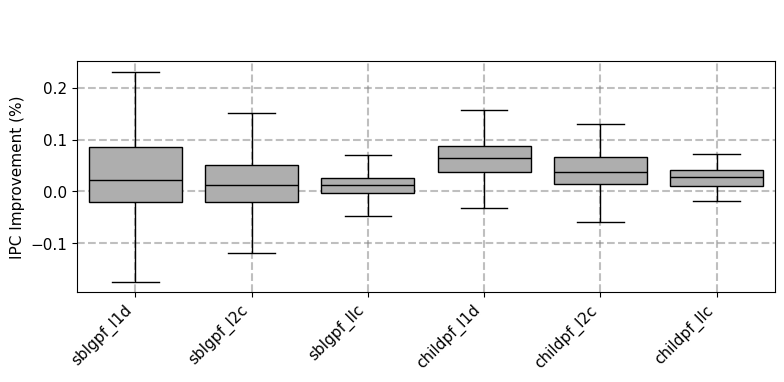

Override applied: EXPERIMENT.workload='google_srv'
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for google_srv
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
           tag  IPC_IMPROVEMENT
0  childpf_l1d         0.027661
1  childpf_l2c         0.007252
4   sblgpf_l2c         0.006005
2  childpf_llc         0.005022
5   sblgpf_llc        -0.004265
3   sblgpf_l1d        -0.011014
sblgpf_l1d:-0.024498201694180387
sblgpf_l2c:-0.0066667840405321204
sblgpf_llc:0.0025641926597859553
childpf_l1d:0.02521619801706667
childpf_l2c:0.006643051169345924
childpf_llc:-0.0026484388468437764
  benchmarks          tag      mean
0       mean   sblgpf_l1d -0.024498
1       mean   sblgpf_l2c -0.006667
2       mean   sblgpf_llc  0.002564
3       mean  childpf_l1d  0.025216
4       mean  c

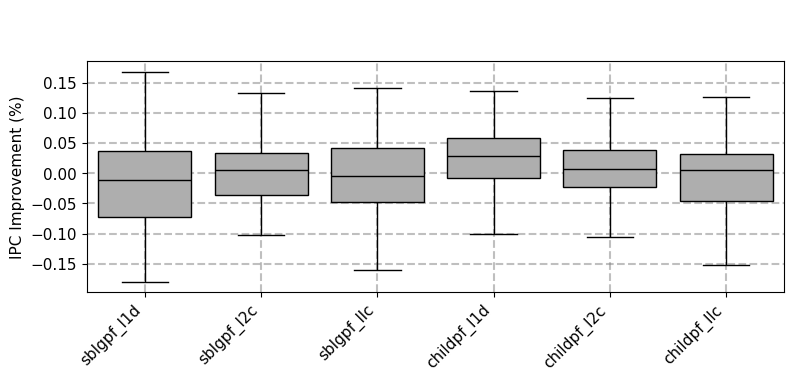

Override applied: EXPERIMENT.workload='gapp'
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
Plotting tx_prefetch_eval_unlimited for gapp
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc', 'childpf_l1d', 'childpf_l2c', 'childpf_llc']
           tag  IPC_IMPROVEMENT
0  childpf_l1d              0.0
1  childpf_l2c              0.0
2  childpf_llc              0.0
3   sblgpf_l1d              0.0
4   sblgpf_l2c              0.0
5   sblgpf_llc              0.0
sblgpf_l1d:0.006527006845600342
sblgpf_l2c:-0.003747486573521007
sblgpf_llc:0.003267194547408964
childpf_l1d:-0.0004601751243279254
childpf_l2c:-0.0001951992792517413
childpf_llc:0.0006793191803924407
  benchmarks          tag      mean
0       mean   sblgpf_l1d  0.006527
1       mean   sblgpf_l2c -0.003747
2       mean   sblgpf_llc  0.003267
3       mean  childpf_l1d -0.000460
4       mean  childpf_l2c 

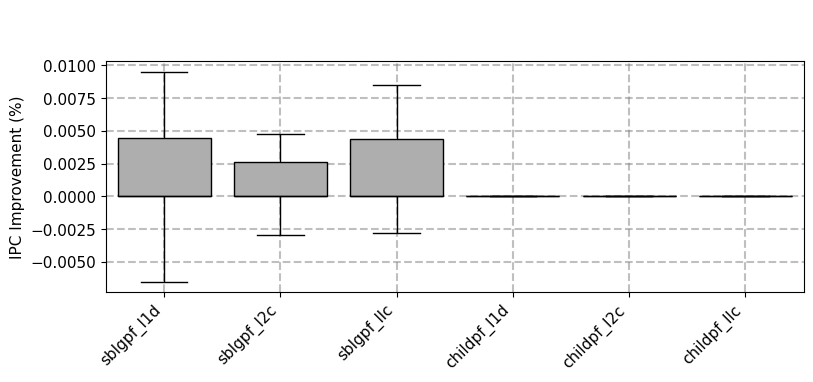

In [8]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.workload=smt_qualcomm_srv_ap" "PLOTTING.file_type=pdf"

from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_ipc_smt_qualcomm_srv_ap.png", 
width=600, height=600))

!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.workload=google_srv" "PLOTTING.file_type=pdf"

from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_ipc_google_srv.png", 
width=600, height=600))

!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.workload=gapp" "PLOTTING.file_type=pdf"

from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_ipc_gapp.png", 
width=600, height=600))


***
### Ideas for vmem prefetcher

* The prediction idea of childred seems to work as a concept
  - Need a more practical version
  - One issue is that there are not many misses on non-leaf PTEs

* Maybe prefetch at LLC, on an earlier event (i.e. STLB miss)
  - If we are to make a pagewalk, try to prefetch at STLB miss in LLC
  - STLB miss will trigger an early speculative page walk
    - We need to guess the l3 parent (l4 is root)

* Measure optimal page walks
  - If all PTEs were at LLC, L2C, L1D respectively
  - check specific levels (i.e. leaf-nodes only)

In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect.ini --build --run

In [6]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_buffer_perfect/BASELINE', './data/tx_buffer_perfect']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
BASELINE/selected_qualcomm_srv_ap_0_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_20_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_40_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_60_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_80_BASELINE_run.out
BASELINE/srv100_ap_BASELINE_run.out
BASELINE/srv103_ap_BASELINE_run.out
BASELINE/srv111_ap_BASELINE_run.out
BASELINE/srv120_ap_BASELINE_run.out
BASELINE/srv121_ap_BASELINE_run.out
BASELINE

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'bf_l1d', 'bf_l2c', 'bf_llc']
Plotting tx_buffer_perfect for selected_qualcomm_srv_ap
['BASELINE', 'bf_l1d', 'bf_l2c', 'bf_llc']
      tag  IPC_IMPROVEMENT
0  bf_l1d         9.235466
1  bf_l2c         8.811880
2  bf_llc         6.258298
bf_l1d:10.441871607622433
bf_l2c:9.565091420151127
bf_llc:6.881964785181404
  benchmarks     tag       mean
0       mean  bf_l1d  10.441872
1       mean  bf_l2c   9.565091
2       mean  bf_llc   6.881965
  benchmarks     tag       mean
0       mean  bf_l1d  10.441872
1       mean  bf_l2c   9.565091
2       mean  bf_llc   6.881965
./figures/tx_buffer_perfect/tx_buffer_perfect_ipc_selected_qualcomm_srv_ap.pdf
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
Plotting completed successfully


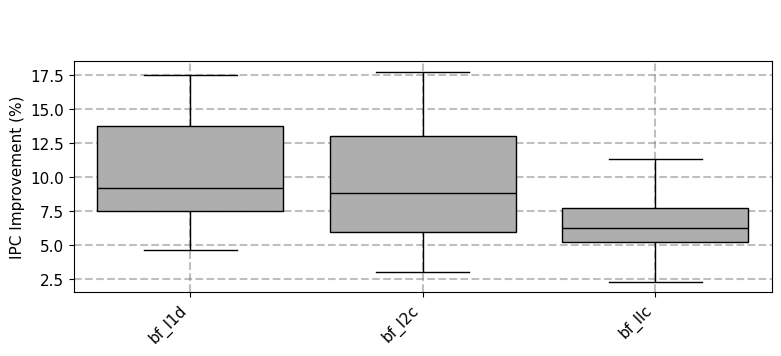

In [1]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect.ini --plot --override "PLOTTING.file_type=pdf"

from IPython.display import Image, display
display(Image("./figures/tx_buffer_perfect/tx_buffer_perfect_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.plot_type='mpki'
Preprocessing configuration file...
['BASELINE', 'bf_l1d', 'bf_l2c', 'bf_llc']
Plotting tx_buffer_perfect for selected_qualcomm_srv_ap
   benchmarks     cache       tag       mean       MPKI
0     geomean  cpu0_L1D  BASELINE  31.863995  31.863995
1     geomean  cpu0_L1D    bf_l1d  47.034485  47.034485
2     geomean  cpu0_L1D    bf_l2c  33.677290  33.677290
3     geomean  cpu0_L1D    bf_llc  32.321268  32.321268
4     geomean  cpu0_L2C  BASELINE   5.859524   5.859524
5     geomean  cpu0_L2C    bf_l1d   6.698487   6.698487
6     geomean  cpu0_L2C    bf_l2c   6.985302   6.985302
7     geomean  cpu0_L2C    bf_llc   5.859230   5.859230
8     geomean       LLC  BASELINE   4.416424   4.416424
9     geomean       LLC    bf_l1d   4.810117   4.810117
10    geomean       LLC    bf_l2c   4.287043   4.287043
11    geomean       LLC    bf_llc   3.918752   3.918752
./figures/tx_buffer_perfect/tx_buffer_perfect_mpki_selected_qu

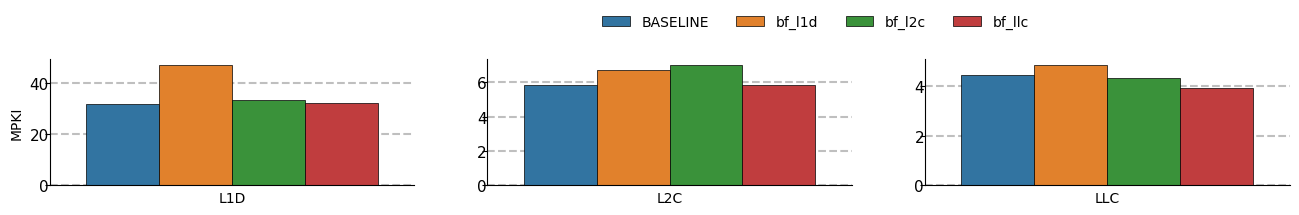

In [8]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect.ini --plot --override "PLOTTING.plot_type=mpki"

from IPython.display import Image, display
display(Image("./figures/tx_buffer_perfect/tx_buffer_perfect_mpki_selected_qualcomm_srv_ap.png", 
width=1000, height=1000))

### Results with no cache fill on buffer hit

In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect_no_cache_fill.ini --build --run

In [3]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect_no_cache_fill.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_buffer_perfect_no_cache_fill/BASELINE', './data/tx_buffer_perfect_no_cache_fill']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list
created directory ./data/tx_buffer_perfect_no_cache_fill
BASELINE/
BASELINE/selected_qualcomm_srv_ap_0_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_20_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_40_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_60_BASELINE_run.out
BASELINE/selected_qualcomm_srv_ap_80_BASELINE_run.out
BASELINE/srv100_ap_BASELINE_run.out
BASELINE/srv103_ap_BASELINE_run.out
BASELINE/srv111_ap_BA

/home/bscuser/synched_mnt/VMem
Override applied: PLOTTING.file_type='pdf'
Preprocessing configuration file...
['BASELINE', 'bf_l1d', 'bf_l2c', 'bf_llc']
Plotting tx_buffer_perfect_no_cache_fill for selected_qualcomm_srv_ap
['BASELINE', 'bf_l1d', 'bf_l2c', 'bf_llc']
      tag  IPC_IMPROVEMENT
1  bf_l2c        10.972186
0  bf_l1d         9.214167
2  bf_llc         8.030945
bf_l1d:10.48887085373223
bf_l2c:11.577303106177622
bf_llc:8.859318583526084
  benchmarks     tag       mean
0       mean  bf_l1d  10.488871
1       mean  bf_l2c  11.577303
2       mean  bf_llc   8.859319
  benchmarks     tag       mean
0       mean  bf_l1d  10.488871
1       mean  bf_l2c  11.577303
2       mean  bf_llc   8.859319
./figures/tx_buffer_perfect_no_cache_fill/tx_buffer_perfect_no_cache_fill_ipc_selected_qualcomm_srv_ap.pdf
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
Plotting completed successfull

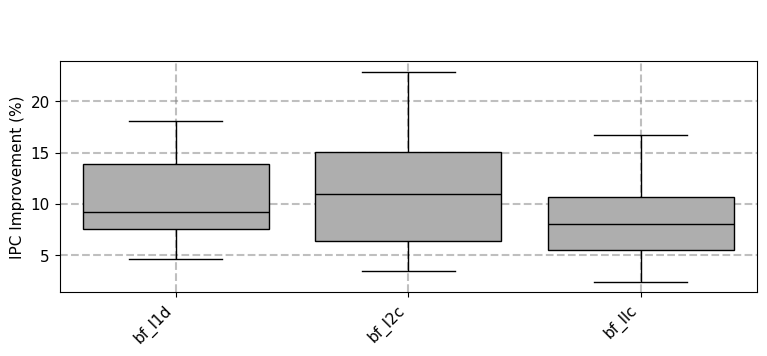

In [3]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_buffer_perfect_no_cache_fill.ini --plot --override "PLOTTING.file_type=pdf"

from IPython.display import Image, display
display(Image("./figures/tx_buffer_perfect_no_cache_fill/tx_buffer_perfect_no_cache_fill_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

***
### Redesign of child_pf

* How we compute a page from PTEs:

  - Step 1 (L4): 
    - L4_table_base = get from CR3
    - L4_index = VPN[47:39] = bits 0-8 of VPN
    - L4_PTE_addr = L4_table_base + (L4_index * 8)
    - L4_PTE_content = read_memory(L4_PTE_addr)
  
  - Step 2 (L3):
    - L3_table_base = L4_PTE_content[51:12] << 12  (extract pointer, convert to bytes)
    - L3_index = VPN[38:30] = bits 9-17 of VPN
    - L3_PTE_addr = L3_table_base + (L3_index * 8)
    - This is the CHILD of the L4 PTE!
  
  - Step 3 (L2):
    - L2_table_base = L3_PTE_content[51:12] << 12
    - L2_index = VPN[29:21] = bits 18-26 of VPN
    - L2_PTE_addr = L2_table_base + (L2_index * 8)
    - This is the CHILD of the L3 PTE!


Goal: Build a page-walk predictor for a multi-level radix-tree page table (e.g., 5 levels).

Assumptions:

* A VPN follows a unique path through the page-table radix tree.
* We can ignore storage and hardware cost for now.
* We are operating within a single address space (or equivalently, ASID/CR3 is implicitly part of every key).

Data Structures

- Table A: PTE Discovery Table

```
      (VPN, level) -> PTE_address
```

This table records the physical address of every PTE that has been observed during a page walk.

Examples:

```
(vpnX, L5) -> pte5
(vpnX, L4) -> pte4
(vpnX, L3) -> pte3
```

Table B: Parent-to-Child Prediction Table

```
(parent_PTE_address, VPN) -> child_PTE_address
```

This table records the child observed beneath a particular parent PTE for a specific VPN.

The VPN is included because the same parent PTE may have many architectural children, and a single VPN determines which child is correct.

Examples:

```
(pte5, vpnX) -> pte4
(pte4, vpnX) -> pte3
(pte3, vpnX) -> pte2
```

Lookup Procedure

Suppose the page walker is currently visiting:

```
(curr_vpn, curr_level, curr_pte_addr)
```

Step 1: Check whether this PTE is already known.

Lookup:

```
(curr_vpn, curr_level)
```

in Table A.

Case A: Hit and stored address equals curr_pte_addr

  The current PTE has been correctly identified.

  Attempt prediction:

    ```
    (curr_pte_addr, curr_vpn)
    ```

  in Table B.

    If found:

    ```
    predicted_child = TableB[(curr_pte_addr, curr_vpn)]
    ```

    Issue a prediction for the next-level PTE.

Case B: Miss (or address mismatch)

Attempt to locate the parent instead.

Lookup:

```
(curr_vpn, curr_level + 1)
```

(or curr_level - 1 depending on numbering convention)

in Table A.

If parent is not found:

```
No prediction possible.
```

If parent is found:

```
parent_addr = TableA[(curr_vpn, parent_level)]
```

Then check:

```
(parent_addr, curr_vpn)
```

in Table B.

Training Procedure

If Table B contains no entry for:

```
(parent_addr, curr_vpn)
```

train it with:

```
(parent_addr, curr_vpn) -> curr_pte_addr
```

This teaches the predictor which child was observed beneath that parent for that VPN.

Afterward, ensure the current node is recorded.

Insert into Table A:

```
(curr_vpn, curr_level) -> curr_pte_addr
```

Also create a placeholder prediction entry for future descendants if desired:

```
(curr_pte_addr, curr_vpn) -> INVALID
```

Later, when a child of curr_pte_addr is observed, this placeholder can be updated.

Key Insight

A VPN determines a unique path through the radix tree. Therefore:

```
(parent_PTE_address, VPN)
```

uniquely identifies the correct child PTE for that VPN, eliminating the ambiguity that would exist with a simpler mapping such as:

```
parent_PTE_address -> child_PTE_address
```

where a parent may have many possible children.


In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --build --run --override "EXPERIMENT.simulations=BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc"

In [13]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.simulations=BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc"

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc'
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,421 bytes  10,314.67 bytes/sec
total size is 7,700,379  speedup is 497.70
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc'
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,421 bytes  10,314.67 bytes/sec
total size is 7,700,379  speedup is 497.70
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*

Merging results to ./stats/tx_prefetch_eval_unlimited/child_ideal_pf_llc/selected_qualcomm_srv_ap_child_ideal_pf_llc.csv
Parsing completed successfully


/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc'
Preprocessing configuration file...
['BASELINE', 'child_ideal_pf_l1d', 'child_ideal_pf_l2c', 'child_ideal_pf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'child_ideal_pf_l1d', 'child_ideal_pf_l2c', 'child_ideal_pf_llc']
                  tag  IPC_IMPROVEMENT
0  child_ideal_pf_l1d         3.652382
1  child_ideal_pf_l2c         1.095976
2  child_ideal_pf_llc         0.342138
child_ideal_pf_l1d:4.5173435197974205
child_ideal_pf_l2c:1.1654801940202801
child_ideal_pf_llc:0.44159628407284623
  benchmarks                 tag      mean
0       mean  child_ideal_pf_l1d  4.517344
1       mean  child_ideal_pf_l2c  1.165480
2       mean  child_ideal_pf_llc  0.441596
  benchmarks                 tag      mean
0       mean  child_ideal_pf_l1d  4.517344
1       mean  child_ideal_pf_l2c  1.165480
2       mean  child_ideal_pf_

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc'
Preprocessing configuration file...
['BASELINE', 'child_ideal_pf_l1d', 'child_ideal_pf_l2c', 'child_ideal_pf_llc']
Plotting tx_prefetch_eval_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'child_ideal_pf_l1d', 'child_ideal_pf_l2c', 'child_ideal_pf_llc']
                  tag  IPC_IMPROVEMENT
0  child_ideal_pf_l1d         3.652382
1  child_ideal_pf_l2c         1.095976
2  child_ideal_pf_llc         0.342138
child_ideal_pf_l1d:4.5173435197974205
child_ideal_pf_l2c:1.1654801940202801
child_ideal_pf_llc:0.44159628407284623
  benchmarks                 tag      mean
0       mean  child_ideal_pf_l1d  4.517344
1       mean  child_ideal_pf_l2c  1.165480
2       mean  child_ideal_pf_llc  0.441596
  benchmarks                 tag      mean
0       mean  child_ideal_pf_l1d  4.517344
1       mean  child_ideal_pf_l2c  1.165480
2       mean  child_ideal_pf_

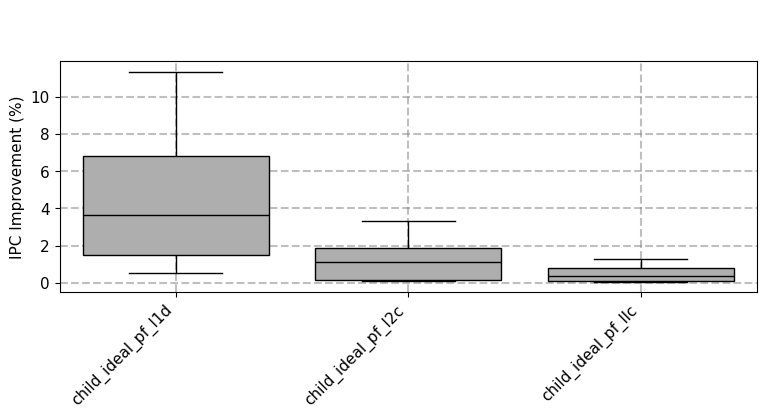

In [15]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.simulations=BASELINE,child_ideal_pf_l1d,child_ideal_pf_l2c,child_ideal_pf_llc"
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_prefetch_eval_unlimited_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

### Child-Ideal Prefetcher Breakdown

Analysis of `child_ideal_pf` prefetcher statistics across cache levels:
- Prediction table hit rates
- Training efficiency
- Table memory usage
- Prefetch issuance rates


- Why don't we see no predictions because of leaf-nodes? 
- Need to go over the new statistics counters carefully, something is not right... 

In [13]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.simulations=BASELINE,child_ideal_pf_nobuff_l1d,child_ideal_pf_nobuff_l2c,child_ideal_pf_nobuff_llc"

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_nobuff_l1d,child_ideal_pf_nobuff_l2c,child_ideal_pf_nobuff_llc'
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,425 bytes  10,317.33 bytes/sec
total size is 7,700,379  speedup is 497.57
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,child_ideal_pf_nobuff_l1d,child_ideal_pf_nobuff_l2c,child_ideal_pf_nobuff_llc'
Override applied: PLOTTING.plot_name='child_ideal_pf_nobuff'
Preprocessing configuration file...
['BASELINE', 'child_ideal_pf_nobuff_l1d', 'child_ideal_pf_nobuff_l2c', 'child_ideal_pf_nobuff_llc']
Plotting child_ideal_pf_nobuff for selected_qualcomm_srv_ap
['BASELINE', 'child_ideal_pf_nobuff_l1d', 'child_ideal_pf_nobuff_l2c', 'child_ideal_pf_nobuff_llc']
                         tag  IPC_IMPROVEMENT
2  child_ideal_pf_nobuff_llc        -0.004977
1  child_ideal_pf_nobuff_l2c        -0.015537
0  child_ideal_pf_nobuff_l1d        -0.142204
child_ideal_pf_nobuff_l1d:-0.1952293549380828
child_ideal_pf_nobuff_l2c:-0.040313355775512275
child_ideal_pf_nobuff_llc:-0.009528842107128498
  benchmarks                        tag      mean
0       mean  child_ideal_pf_nobuff_l1d -0.195229
1       mean  child_ideal_pf_nobuff_l2c -0.040313
2     

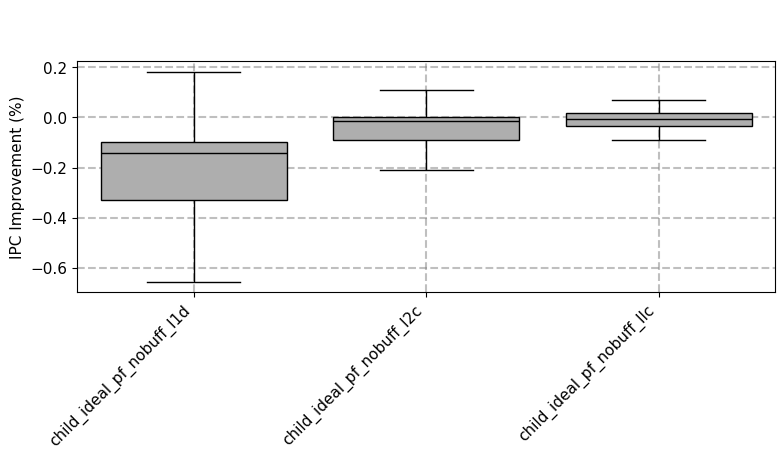

In [ ]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.simulations=BASELINE,child_ideal_pf_nobuff_l1d,child_ideal_pf_nobuff_l2c,child_ideal_pf_nobuff_llc" "PLOTTING.plot_name=child_ideal_pf_nobuff" "PLOTTING.file_type=pdf"
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/child_ideal_pf_nobuff_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

***
### Sibling Prefetcher

In [ ]:
./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --build --override "EXPERIMENT.simulations=BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc" --run


In [8]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --parse --override "EXPERIMENT.simulations=BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc"

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc'
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,421 bytes  30,944.00 bytes/sec
total size is 7,700,379  speedup is 497.70
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc'
Override applied: PLOTTING.plot_name='sibling_pf'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc']
Plotting sibling_pf for selected_qualcomm_srv_ap
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc']
          tag  IPC_IMPROVEMENT
0  sblgpf_l1d         0.001946
1  sblgpf_l2c         0.000000
2  sblgpf_llc         0.000000
sblgpf_l1d:0.005236211811899422
sblgpf_l2c:0.0013274797255445427
sblgpf_llc:0.0008160920566237191
  benchmarks         tag      mean
0       mean  sblgpf_l1d  0.005236
1       mean  sblgpf_l2c  0.001327
2       mean  sblgpf_llc  0.000816
  benchmarks         tag      mean
0       mean  sblgpf_l1d  0.005236
1       mean  sblgpf_l2c  0.001327
2       mean  sblgpf_llc  0.000816
./figures/tx_prefetch_eval_unlimited/sibling_pf_ipc_selected_qualcomm_srv_ap.png
No artists with labels found to put in legend.  Note tha

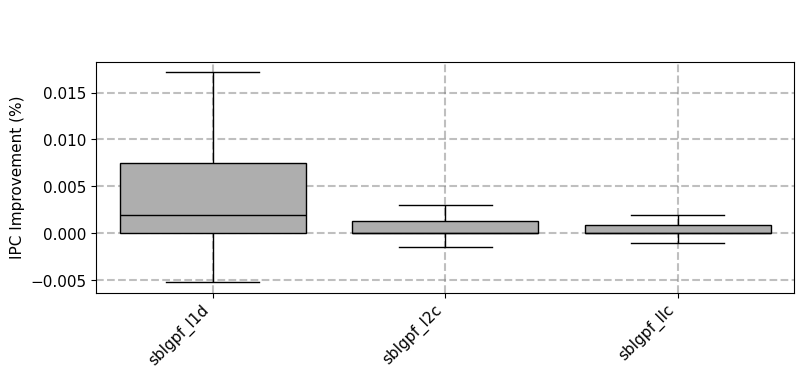

In [9]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.simulations=BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc" "PLOTTING.plot_name=sibling_pf"
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/sibling_pf_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

/home/bscuser/synched_mnt/VMem
Override applied: EXPERIMENT.simulations='BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc'
Override applied: PLOTTING.plot_name='sibling_pf'
Override applied: PLOTTING.plot_type='prefetch_accuracy'
Preprocessing configuration file...
['BASELINE', 'sblgpf_l1d', 'sblgpf_l2c', 'sblgpf_llc']
Plotting sibling_pf for selected_qualcomm_srv_ap
./figures/tx_prefetch_eval_unlimited/sibling_pf_prefetch_accuracy_selected_qualcomm_srv_ap.png

=== PREFETCH_ACCURACY Statistics (%) ===
sblgpf_l1d           count= 93  min=  0.00  q1=316.67  median=1566.67  q3=3766.67  max=19533.33  mean=2953.75
sblgpf_l2c           count= 76  min=  0.00  q1= 31.25  median=100.00  q3=640.00  max=6000.00  mean=485.53
sblgpf_llc           count= 87  min=  0.00  q1= 20.83  median= 75.00  q3=220.00  max=1271.43  mean=190.18

Plotting completed successfully


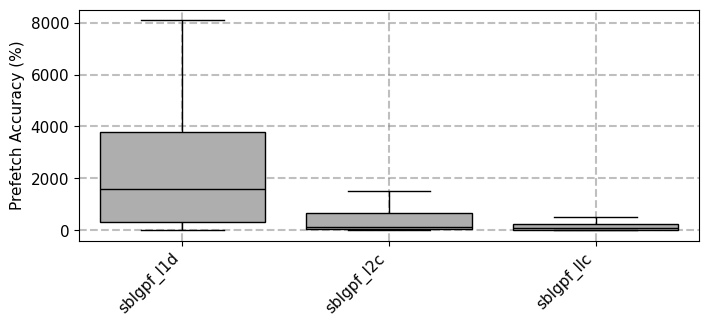

In [10]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_prefetch_eval_unlimited.ini --plot --override "EXPERIMENT.simulations=BASELINE,sblgpf_l1d,sblgpf_l2c,sblgpf_llc" "PLOTTING.plot_name=sibling_pf" "PLOTTING.plot_type=prefetch_accuracy"
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/sibling_pf_prefetch_accuracy_selected_qualcomm_srv_ap.png", 
width=600, height=600))

In [1]:
# Raw .out-based ChildPF breakdown: parse `PF ENTRY-LIFETIME` and `PF DROP-REASONS` lines
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()
#all_sims = [s.strip() for s in config["EXPERIMENT"]["simulations"].split(",") if s.strip()]
#child_sims = [s for s in all_sims if "child_ideal" in s.lower()]

child_sims = ["child_ideal_pf_l1d", "child_ideal_pf_l2c", "child_ideal_pf_llc" ]

data_root = base_dir / "data" / exp_name
fig_root = base_dir / "figures" / exp_name / "childpf_raw_out_breakdown"
fig_root.mkdir(parents=True, exist_ok=True)

rows = []
for sim in child_sims:
    sim_dir = data_root / sim
    if not sim_dir.exists():
        print(f"Skipping {sim}: missing data dir")
        continue
    out_files = list(sim_dir.glob("*.out"))
    if not out_files:
        print(f"Skipping {sim}: no .out files")
        continue

    # aggregate counters
    ent = {
        'ALLOC': 0,
        'REPL': 0,
        'REPL_BEFORE_ISSUE': 0,
        'REPL_AFTER_ISSUE': 0,
        'AVG_REPL_LIFETIME_TICKS': 0.0,
        'LIVE': 0,
        'LIVE_WITH_ISSUE': 0,
    }
    drops = {
        'NO_PENDING_PARENT': 0,
        'PENDING_OVERWRITE_COLLISION': 0,
        #'TRAIN_REPLACE_MISMATCH': 0,
        'LEAF_NO_PREDICT': 0,
        'PRED_INVALID': 0,
        'PRED_ISSUED': 0,
        'ISSUE_MSHR_BLOCKED': 0,
        'ISSUE_ENQUEUE_FAILED': 0,
    }
    # unique counts storage parsed from stdout PF UNIQUE COUNTS line
    unique_counts = {
        'TOTAL_PTES_OBSERVED': 0,
        'TOTAL_UNIQUE_PTES_OBSERVED': 0,
        'TOTAL_UNIQUE_PARENTS_OBSERVED': 0,
        'TOTAL_UNIQUE_CHILDREN_OBSERVED': 0,
        'TOTAL_UNIQUE_PARENT_CHILD_PAIRS_OBSERVED': 0,
        'TOTAL_UNIQUE_PARENT_CHILD_PAIRS_WITH_REPLACEMENT_OBSERVED': 0,
    }
    seen_any = False

    for out_file in out_files:
        text = out_file.read_text(errors='ignore')
        for line in text.splitlines():
            if 'PF ENTRY-LIFETIME' in line:
                seen_any = True
                pairs = re.findall(r'([A-Z_]+):(\d+(?:\.\d+)?)', line)
                for k, v in pairs:
                    if k in ent:
                        if '.' in v:
                            ent[k] = float(ent[k]) + float(v)
                        else:
                            ent[k] = ent[k] + int(v)
            if 'PF UNIQUE COUNTS' in line:
                seen_any = True
                # parse key:val pairs from PF UNIQUE COUNTS line
                pairs = re.findall(r'([A-Z_]+):(\d+)', line)
                for k, v in pairs:
                    if k in unique_counts:
                        unique_counts[k] = int(v)
            if 'PF DROP-REASONS' in line:
                seen_any = True
                pairs = re.findall(r'([A-Z0-9_]+):(\d+)', line)
                for k, v in pairs:
                    if k in drops:
                        drops[k] += int(v)

    if not seen_any:
        print(f"Skipping {sim}: no PF ENTRY-LIFETIME / PF DROP-REASONS in .out files")
        continue

    # Build row
    total_drop = float(sum(drops.values()))
    row = {
        'sim': sim,
        'total_drop': total_drop,
        'no_pending_parent': float(drops['NO_PENDING_PARENT']),
        'pending_overwrite_collision': float(drops['PENDING_OVERWRITE_COLLISION']),
        #'train_replace_mismatch': float(drops['TRAIN_REPLACE_MISMATCH']),
        'leaf_no_predict': float(drops['LEAF_NO_PREDICT']),
        'pred_invalid': float(drops['PRED_INVALID']),
        'pred_issued': float(drops['PRED_ISSUED']),
        'backend_blocked': float(drops['ISSUE_MSHR_BLOCKED'] + drops['ISSUE_ENQUEUE_FAILED']),
        'alloc': float(ent['ALLOC']),
        'repl': float(ent['REPL']),
        'repl_before_issue': float(ent['REPL_BEFORE_ISSUE']),
        'repl_after_issue': float(ent['REPL_AFTER_ISSUE']),
        'live': float(ent['LIVE']),
        'live_with_issue': float(ent['LIVE_WITH_ISSUE']),
        'avg_repl_lifetime_ticks': float(ent['AVG_REPL_LIFETIME_TICKS']),
        # Unique counts (parsed from PF UNIQUE COUNTS stdout line)
        'total_ptes_observed': float(unique_counts.get('TOTAL_PTES_OBSERVED', 0)),
        'total_unique_ptes_observed': float(unique_counts.get('TOTAL_UNIQUE_PTES_OBSERVED', 0)),
        'total_unique_parents_observed': float(unique_counts.get('TOTAL_UNIQUE_PARENTS_OBSERVED', 0)),
        'total_unique_children_observed': float(unique_counts.get('TOTAL_UNIQUE_CHILDREN_OBSERVED', 0)),
        'total_unique_parent_child_pairs_observed': float(unique_counts.get('TOTAL_UNIQUE_PARENT_CHILD_PAIRS_OBSERVED', 0)),
        'total_unique_parent_child_pairs_with_replacement_observed': float(unique_counts.get('TOTAL_UNIQUE_PARENT_CHILD_PAIRS_WITH_REPLACEMENT_OBSERVED', 0)),
    }
    rows.append(row)

if not rows:
    raise RuntimeError('No child PF data parsed from raw .out files')

res = pd.DataFrame(rows).sort_values('sim').reset_index(drop=True)

# Percent views (use the exact drop reasons provided)
for c in ['no_pending_parent','pending_overwrite_collision','leaf_no_predict','pred_invalid','pred_issued','backend_blocked']:
    res[f"{c}_pct"] = np.where(res['total_drop'] > 0, 100.0 * res[c] / res['total_drop'], 0.0)

# Entry-pressure counts (absolute values)
res['repl_over_alloc_pct'] = np.where(res['alloc'] > 0, 100.0 * res['repl'] / res['alloc'], 0.0)
res['repl_before_issue_over_repl_pct'] = np.where(res['repl'] > 0, 100.0 * res['repl_before_issue'] / res['repl'], 0.0)
res['live_with_issue_over_live_pct'] = np.where(res['live'] > 0, 100.0 * res['live_with_issue'] / res['live'], 0.0)

print('ChildPF (raw .out) aggregate counters:')
show_cols = [
    'sim','total_drop','no_pending_parent','pending_overwrite_collision','leaf_no_predict','pred_invalid','pred_issued','backend_blocked',
    'repl_over_alloc_pct','repl_before_issue_over_repl_pct','live_with_issue_over_live_pct'
]
print(res[show_cols].round(2).to_string(index=False))

# 1) Stacked drop/outcome composition
stack_cols = ['no_pending_parent_pct','pending_overwrite_collision_pct','leaf_no_predict_pct','pred_invalid_pct','pred_issued_pct','backend_blocked_pct']
stack_labels = ['No pending parent','Pending overwrite','Leaf no predict','Pred invalid','Issued','Backend blocked']
plot_stack = res[['sim'] + stack_cols].copy()
plot_stack.columns = ['sim'] + stack_labels
plot_stack = plot_stack.set_index('sim')
fig, ax = plt.subplots(figsize=(11,6))
plot_stack.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('ChildPF (raw): Drop/Outcome Composition (%)')
ax.set_xlabel('Experiment')
ax.set_ylabel('Percent of total drop/outcome events (%)')
ax.set_ylim(0,100)
ax.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
out1 = fig_root / 'childpf_raw_drop_composition_stacked_pct.png'
plt.savefig(out1, dpi=160, bbox_inches='tight')
plt.show()
plt.close()

# 3) Entry-pressure counts (absolute values)
abs_cols = ['alloc', 'repl', 'repl_before_issue', 'repl_after_issue', 'live', 'live_with_issue']
# Print the absolute entry-pressure table similar to figure 1's printed summary
print('\nChildPF entry-pressure absolute counts:')
print(res[['sim'] + abs_cols].round(2).to_string(index=False))

abs_long = res[['sim'] + abs_cols].melt(id_vars='sim', var_name='metric', value_name='count')
abs_long['metric'] = abs_long['metric'].map({
    'alloc': 'Allocations',
    'repl': 'Replacements',
    'repl_before_issue': 'Repl before issue',
    'repl_after_issue': 'Repl after issue',
    'live': 'Live entries',
    'live_with_issue': 'Live with issue',
})
plt.figure(figsize=(11,5))
ax = sns.barplot(data=abs_long, x='sim', y='count', hue='metric', palette='Dark2')
ax.set_title('ChildPF (raw): Entry Pressure (counts)')
ax.set_xlabel('Experiment')
ax.set_ylabel('Count')
ax.legend(title='Metric')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
out3 = fig_root / 'childpf_raw_entry_pressure_counts.png'
plt.savefig(out3, dpi=160, bbox_inches='tight')
plt.show()
plt.close()

# --- New: Unique counts bar plot ---
unique_cols = [
    'total_ptes_observed',
    'total_unique_ptes_observed',
    'total_unique_parents_observed',
    'total_unique_children_observed',
    'total_unique_parent_child_pairs_observed',
    'total_unique_parent_child_pairs_with_replacement_observed',
]
# Print unique counts table similar to figure 1's printed summary
print('\nChildPF PF UNIQUE COUNTS (per experiment):')
# avoid converting the 'sim' column to int by converting only numeric columns
display_unique = res[['sim'] + unique_cols].copy()
display_unique[unique_cols] = display_unique[unique_cols].round(0).astype(int)
print(display_unique.to_string(index=False))

# melt for plotting (show absolute counts per sim)
unique_long = res[['sim'] + unique_cols].melt(id_vars='sim', var_name='metric', value_name='count')
# map nicer labels
unique_long['metric'] = unique_long['metric'].map({
    'total_ptes_observed': 'Total PTEs Observed',
    'total_unique_ptes_observed': 'Unique PTEs',
    'total_unique_parents_observed': 'Unique Parents',
    'total_unique_children_observed': 'Unique Children',
    'total_unique_parent_child_pairs_observed': 'Unique Parent-Child Pairs',
    'total_unique_parent_child_pairs_with_replacement_observed': 'Parent-Child Pairs w/ Replacement',
})
plt.figure(figsize=(12,6))
ax = sns.barplot(data=unique_long, x='sim', y='count', hue='metric', dodge=True, palette='tab10')
ax.set_title('ChildPF (raw): PF Unique Counts (absolute)') 
ax.set_xlabel('Experiment')
ax.set_ylabel('Count')
ax.legend(title='Unique Count')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
out_unique = fig_root / 'childpf_raw_unique_counts.png'
plt.savefig(out_unique, dpi=160, bbox_inches='tight')
plt.show()
plt.close()

print(f"\nSaved: {out1}")
print(f"Saved: {out3}")
print(f"Saved: {out_unique}")


/home/bscuser/synched_mnt/VMem
ChildPF (raw .out) aggregate counters:
               sim  total_drop  no_pending_parent  pending_overwrite_collision  leaf_no_predict  pred_invalid  pred_issued  backend_blocked  repl_over_alloc_pct  repl_before_issue_over_repl_pct  live_with_issue_over_live_pct
child_ideal_pf_l1d  27202995.0          1122145.0                          0.0       18517999.0           4.0    4016408.0        3546439.0              1602.19                            61.69                         958.33
child_ideal_pf_l2c  20883575.0           930044.0                          0.0       16525247.0           8.0    3428186.0             90.0              7577.88                            63.18                        3139.66
child_ideal_pf_llc  11919924.0           297434.0                          0.0       10904799.0        4786.0     712905.0              0.0              2682.95                            82.79                         651.99


KeyboardInterrupt: 

/home/bscuser/synched_mnt/VMem
SiblingPF (raw .out) aggregate counters:
       sim  total_drop  uc_disabled  pred_invalid  pred_tag_mismatch  pred_conf_blocked  pred_zero_delta  pred_issued  backend_blocked
sblgpf_l1d  24952749.0          0.0      524867.0                0.0         18669593.0        1698394.0        985.0        4058910.0
sblgpf_l2c  11945994.0          0.0      526062.0                0.0         10401375.0        1017965.0        592.0              0.0
sblgpf_llc   9137642.0          0.0      526060.0                0.0          8001619.0         609286.0        677.0              0.0


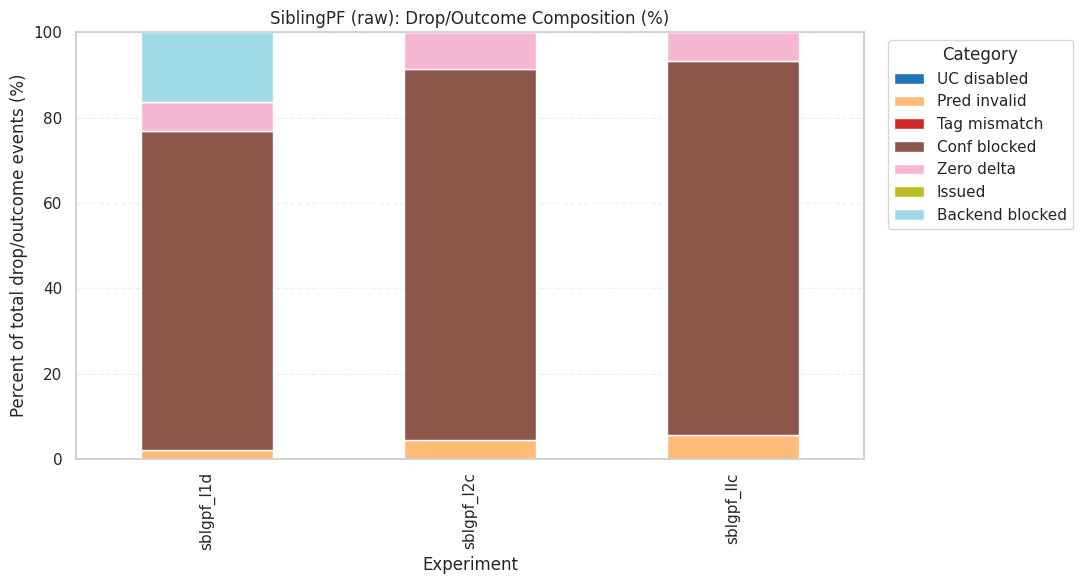

/home/bscuser/synched_mnt/VMem/figures/tx_prefetch_eval_unlimited/siblingpf_raw_out_breakdown/siblingpf_raw_drop_composition_stacked_pct.pdf


In [5]:
# Raw .out-based SiblingPF breakdown: parse `PF ENTRY-LIFETIME` and `PF DROP-REASONS` lines
%cd /home/bscuser/synched_mnt/VMem

from pathlib import Path
import configparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

cfg_path = base_dir / "exp_conf" / "tx_prefetch_eval_unlimited.ini"
config = configparser.ConfigParser()
config.read(cfg_path)

exp_name = config["EXPERIMENT"]["name"].strip()
workload = config["EXPERIMENT"]["workload"].strip()
sibling_sims = ["sblgpf_l1d", "sblgpf_l2c", "sblgpf_llc"]

data_root = base_dir / "data" / exp_name
fig_root = base_dir / "figures" / exp_name / "siblingpf_raw_out_breakdown"
fig_root.mkdir(parents=True, exist_ok=True)

rows = []
for sim in sibling_sims:
    sim_dir = data_root / sim
    if not sim_dir.exists():
        print(f"Skipping {sim}: missing data dir")
        continue
    out_files = list(sim_dir.glob("*.out"))
    if not out_files:
        print(f"Skipping {sim}: no .out files")
        continue

    # aggregate counters
    drops = {
        'UC_DISABLED': 0,
        'PRED_INVALID': 0,
        'PRED_TAG_MISMATCH': 0,
        'PRED_CONF_BLOCKED': 0,
        'PRED_ZERO_DELTA': 0,
        'PRED_ISSUED': 0,
        'ISSUE_MSHR_BLOCKED': 0,
        'ISSUE_ENQUEUE_FAILED': 0,
    }

    seen_any = False

    for out_file in out_files:
        text = out_file.read_text(errors='ignore')
        for line in text.splitlines():
            if 'PF DROP-REASONS' in line:
                seen_any = True
                pairs = re.findall(r'([A-Z0-9_]+):(\d+)', line)
                for k, v in pairs:
                    if k in drops:
                        drops[k] += int(v)

    if not seen_any:
        print(f"Skipping {sim}: no PF ENTRY-LIFETIME / PF DROP-REASONS in .out files")
        continue

    # Build row
    total_drop = float(sum(drops.values()))
    row = {
        'sim': sim,
        'total_drop': total_drop,
        'uc_disabled': float(drops['UC_DISABLED']),
        'pred_invalid': float(drops['PRED_INVALID']),
        'pred_tag_mismatch': float(drops['PRED_TAG_MISMATCH']),
        'pred_conf_blocked': float(drops['PRED_CONF_BLOCKED']),
        'pred_zero_delta': float(drops['PRED_ZERO_DELTA']),
        'pred_issued': float(drops['PRED_ISSUED']),
        'backend_blocked': float(drops['ISSUE_MSHR_BLOCKED'] + drops['ISSUE_ENQUEUE_FAILED'])
    }
    rows.append(row)

if not rows:
    raise RuntimeError('No sibling PF data parsed from raw .out files')

res = pd.DataFrame(rows).sort_values('sim').reset_index(drop=True)

# Percent views (use the exact drop reasons provided)
for c in ['uc_disabled','pred_invalid','pred_tag_mismatch','pred_conf_blocked','pred_zero_delta','pred_issued','backend_blocked']:
    res[f"{c}_pct"] = np.where(res['total_drop'] > 0, 100.0 * res[c] / res['total_drop'], 0.0)

print('SiblingPF (raw .out) aggregate counters:')
show_cols = [
    'sim','total_drop','uc_disabled','pred_invalid','pred_tag_mismatch','pred_conf_blocked','pred_zero_delta','pred_issued','backend_blocked'
]
print(res[show_cols].round(2).to_string(index=False))

# 1) Stacked drop/outcome composition
stack_cols = ['uc_disabled_pct','pred_invalid_pct','pred_tag_mismatch_pct','pred_conf_blocked_pct','pred_zero_delta_pct','pred_issued_pct','backend_blocked_pct']
stack_labels = ['UC disabled','Pred invalid','Tag mismatch','Conf blocked','Zero delta','Issued','Backend blocked']
plot_stack = res[['sim'] + stack_cols].copy()
plot_stack.columns = ['sim'] + stack_labels
plot_stack = plot_stack.set_index('sim')
fig, ax = plt.subplots(figsize=(11,6))
plot_stack.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('SiblingPF (raw): Drop/Outcome Composition (%)')
ax.set_xlabel('Experiment')
ax.set_ylabel('Percent of total drop/outcome events (%)')
ax.set_ylim(0,100)
ax.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
out1_sibling = fig_root / 'siblingpf_raw_drop_composition_stacked_pct.pdf'
plt.savefig(out1_sibling, dpi=160, bbox_inches='tight')
plt.show()
plt.close()
print(out1_sibling)

* Figures 2,3 seem weird.  Figure 2 has very low counts, figure 3 seems to have very low parents-children numbers, the unique PTEs must be in at least one of the two categories.
* 

In [ ]:
!./scripts/manage_experiment.py --config exp_conf/tx_child_pf_unlimited.ini --build --run

In [1]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_child_pf_unlimited.ini --parse


/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/BASELINE', './data/tx_prefetch_eval_unlimited']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 15,425 bytes  30,952.00 bytes/sec
total size is 7,700,379  speedup is 497.57
Parsing results for BASELINE...
Merging results to ./stats/tx_prefetch_eval_unlimited/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/tx_prefetch_eval_unlimited/child_ideal

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'child_ideal_pf_gate-75_l1d', 'child_ideal_pf_gate-95_l1d', 'child_ideal_pf_gate-95_l2c', 'child_ideal_pf_gate-75_llc', 'child_ideal_pf_gate-95_llc']
Plotting tx_child_pf_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'child_ideal_pf_gate-75_l1d', 'child_ideal_pf_gate-95_l1d', 'child_ideal_pf_gate-95_l2c', 'child_ideal_pf_gate-75_llc', 'child_ideal_pf_gate-95_llc']
                          tag  IPC_IMPROVEMENT
2  child_ideal_pf_gate-95_l1d         3.427564
0  child_ideal_pf_gate-75_l1d         3.411233
3  child_ideal_pf_gate-95_l2c         0.829630
1  child_ideal_pf_gate-75_llc         0.299885
4  child_ideal_pf_gate-95_llc         0.299885
child_ideal_pf_gate-75_l1d:4.351758377380893
child_ideal_pf_gate-95_l1d:4.354455037026366
child_ideal_pf_gate-95_l2c:0.8339091775045017
child_ideal_pf_gate-75_llc:0.3963070736400758
child_ideal_pf_gate-95_llc:0.3963070736400758
  benchmarks                         

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'child_ideal_pf_gate-75_l1d', 'child_ideal_pf_gate-95_l1d', 'child_ideal_pf_gate-95_l2c', 'child_ideal_pf_gate-75_llc', 'child_ideal_pf_gate-95_llc']
Plotting tx_child_pf_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'child_ideal_pf_gate-75_l1d', 'child_ideal_pf_gate-95_l1d', 'child_ideal_pf_gate-95_l2c', 'child_ideal_pf_gate-75_llc', 'child_ideal_pf_gate-95_llc']
                          tag  IPC_IMPROVEMENT
2  child_ideal_pf_gate-95_l1d         3.427564
0  child_ideal_pf_gate-75_l1d         3.411233
3  child_ideal_pf_gate-95_l2c         0.829630
1  child_ideal_pf_gate-75_llc         0.299885
4  child_ideal_pf_gate-95_llc         0.299885
child_ideal_pf_gate-75_l1d:4.351758377380893
child_ideal_pf_gate-95_l1d:4.354455037026366
child_ideal_pf_gate-95_l2c:0.8339091775045017
child_ideal_pf_gate-75_llc:0.3963070736400758
child_ideal_pf_gate-95_llc:0.3963070736400758
  benchmarks                         

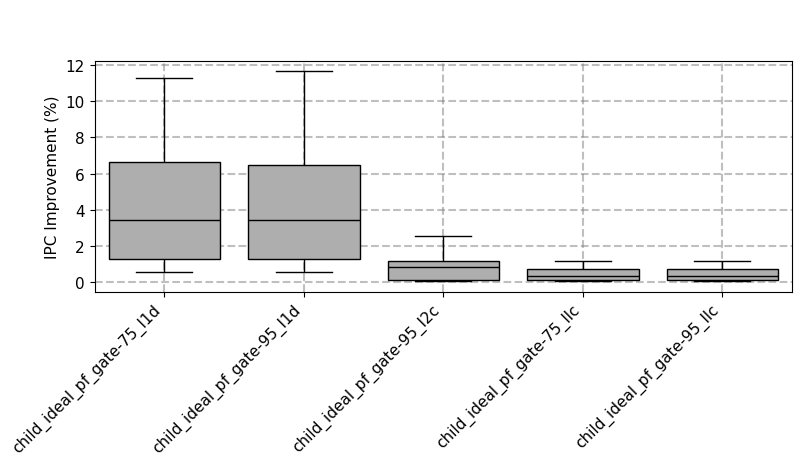

In [3]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/tx_child_pf_unlimited.ini --plot
from IPython.display import Image, display
display(Image("./figures/tx_prefetch_eval_unlimited/tx_child_pf_unlimited_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))